# Fitting the eigenbasis to a Zernike state

Finds the coefficients of Milo's eigenbasis (`eigenbasis_v1.npy`) whose OPD best matches the Zernike OPD stored in a fitted
state (`final_statev46.npy`), for every aberration key. The same fit as `fourier_ab_fit.ipynb`, with the eigenbasis in place of
the orthogonalised Fourier basis.

The eigenbasis is different in kind from the pipeline's per-hole bases:
- each mode spans the **whole pupil** (all seven holes), so a key has one coefficient per mode, `(N_EIGEN,)`, not `(n_holes, 28)`;
- its support is the seven oversized hexagons (`f2f × OVERSIZE`) at the nominal hole positions, and it is orthonormal there;
- global piston, tip, tilt and defocus have been projected out of it (per-hole pistons, tips and tilts are kept).

The Zernike OPD does contain global piston / tip / tilt / defocus, which the eigenbasis cannot represent by construction. With
`FIT_GLOBAL = True` those four terms are fitted alongside as nuisance parameters and reported separately, so the residual
only measures what the eigenbasis itself misses. (In the model, global piston is irrelevant, global tip/tilt is degenerate
with the source position, and defocus has its own `defocus` parameter.)

The Zernike OPD is built with the pipeline's own objects (`AMIOptics(static=False, sparse=True)` → `DynamicApertureMask`,
`eval_small_basis`) with the state's fitted `distortion` / `primary_beam`, and the two are compared over the **fitted
aperture** (`sparse_apertures`, soft edges as weights, each hole weighted equally).

The loss is quadratic in the coefficients, so the optimum is a weighted least-squares solve. The optax loop fits the way the
retrain does; the closed-form solve is computed alongside as a check that the loop reached the optimum.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as np
import numpy as onp
import optax
from jax import vmap

import dLux.utils as dlu
import amigo
from amigo import optical_models as om
from amigo.optical_models import AMIOptics, eval_small_basis

import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
import os

plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["font.size"] = 8

seismic = mpl.colormaps["seismic"]
seismic.set_bad("k", 0.5)

load_dict = lambda x: onp.load(f"{x}", allow_pickle=True).item()

print(jax.local_devices()[0].device_kind, "| amigo", amigo.__version__)

NVIDIA H200 | amigo 0.0.10


In [2]:
from socket import gethostname

if gethostname() in ("maxs-mbp-14.shared.sydney.edu.au", "Maxs-MacBook-Pro-14.local"):
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
elif gethostname().startswith("max-"):
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
else:
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
print(f"amigo_files_path: {amigo_files_path}")

# ---- knobs -----------------------------------------------------------------
STATE_NAME = "final_statev46"
EIGEN_NAME = "eigenbasis_v1"  # Milo's pupil-wide eigenbasis, (N, 1024, 1024), NaN outside its support
N_EIGEN = 100  # first n eigenmodes to use
FIT_GLOBAL = True  # also fit global piston / tip / tilt / defocus (not in the eigenbasis) as nuisance terms
RADIAL_ORDERS = 7  # Zernike basis the state was fitted with (7 -> 28 Noll modes)
F2F, OVERSIZE = 0.80, 1.2
DIAMETER, NPIX = 6.603464, 1024

EPOCHS = 20000
SAVE = True  # write a copy of the state with the fitted eigenbasis coefficients next to the state

state = load_dict(os.path.join(amigo_files_path, STATE_NAME + ".npy"))
keys = list(state["aberrations"])
print(f"{len(keys)} aberration keys, each {state['aberrations'][keys[0]].shape}")

amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11
33 aberration keys, each (7, 28)


## 1. Pipeline optics with the fitted aperture
The Zernike `AMIOptics` the state was fitted with, with the state's fitted aperture geometry.

In [3]:
kw = dict(radial_orders=RADIAL_ORDERS, static=False, sparse=True, f2f=F2F, oversize=OVERSIZE)
optics_z = AMIOptics(**kw)

geometry = ["pupil_mask.transformation.distortion", "pupil_mask.primary_beam"]
values = [np.asarray(state["distortion"]), np.asarray(state["primary_beam"])]
optics_z = optics_z.set(geometry, values)
pm_z = optics_z.pupil_mask
basis_z = pm_z.abb_basis

# per-hole fitted apertures (n_holes, 180, 180): what the model multiplies the wavefront by
mask = pm_z.sparse_apertures(NPIX, DIAMETER)
n_holes, SIZE = mask.shape[0], mask.shape[-1]
print("fitted aperture vs the state's saved transmission:",
      float(np.abs(pm_z.calc_mask(NPIX, DIAMETER) - state["transmission"]).max()))

fitted aperture vs the state's saved transmission: 3.3306690738754696e-16


## 2. The eigenbasis
Each pupil-wide mode is cut into the same per-hole windows as the pipeline's bases, `(N_EIGEN, n_holes, 180, 180)`. The
oversized hexagons don't overlap, so this is exact (checked below). Modes are rescaled to RMS 1 over the support and carry
the pipeline's `1e-9`, so coefficients are in nm.

The global terms are piston, tip, tilt and defocus over the same support, Gram-Schmidt orthogonalised in that order and
scaled to RMS 1, so their coefficients are also in nm.

In [4]:
coords = dlu.pixel_coords(NPIX, DIAMETER)
holes = om.get_initial_holes(DIAMETER, NPIX)
hole_coords = vmap(dlu.translate_coords, (None, 0))(coords, holes)
corners = pm_z.corners
small = om.crop_hole_coords(hole_coords, corners, SIZE)
pix = DIAMETER / NPIX
supp = onp.asarray(vmap(lambda c: dlu.soft_reg_polygon(c, F2F * OVERSIZE / np.sqrt(3), 6, pix))(small)) > 0
n_supp = supp.sum()
crop = lambda a: onp.asarray(om.crop_windows(np.asarray(a), corners, SIZE))

E_full = onp.load(os.path.join(amigo_files_path, EIGEN_NAME + ".npy"), mmap_mode="r")[:N_EIGEN]
eigen = onp.stack([crop(onp.nan_to_num(E_full[k])) for k in range(len(E_full))]) * supp  # (N_EIGEN, n_holes, S, S)
n_eig = eigen.shape[0]

supp_full = onp.asarray(om.fill(np.asarray(supp, float), corners, NPIX)) > 0
print(f"{n_eig} modes; support matches the oversized hexagons pixel for pixel: {bool((onp.isfinite(E_full[0]) == supp_full).all())}")
ss = (eigen**2).sum((1, 2, 3))
print(f"sum of squares kept by the windows (1 = nothing lost or double-counted): min {ss.min():.12f}, max {ss.max():.12f}")
basis_e = 1e-9 * onp.sqrt(n_supp) * eigen  # RMS 1 over the support, coefficients in nm

# global piston, tip, tilt, defocus over the support: Gram-Schmidt in that order, RMS 1
gx, gy = crop(coords[0]), crop(coords[1])
G = onp.stack([onp.ones_like(gx), gx, gy, gx**2 + gy**2])[:, supp]
Q = onp.linalg.qr(G.T)[0].T * onp.sign(onp.diag(onp.linalg.qr(G.T)[1]))[:, None]
glob = onp.zeros((4, *supp.shape))
glob[:, supp] = Q * onp.sqrt(n_supp)
basis_g = 1e-9 * glob
GLOBAL_LABELS = ["piston", "tip", "tilt", "defocus"]
print("eigenmodes' largest overlap with the global terms (should be ~0):",
      onp.abs(eigen[:, supp] @ Q.T).max())

B = onp.concatenate([basis_e, basis_g]) if FIT_GLOBAL else basis_e  # (n_basis, n_holes, S, S)
n_basis = B.shape[0]


def pupil_cond(V, m):
    # condition number of the normalised pupil-wide inner products over the soft mask m
    v = V.reshape(V.shape[0], -1) * onp.sqrt(onp.asarray(m).reshape(-1))
    G_ = v @ v.T
    d = onp.sqrt(onp.diag(G_))
    return onp.linalg.cond(G_ / onp.outer(d, d))


print(f"condition number over the fitted aperture: eigenbasis {pupil_cond(basis_e, mask):.2f}, "
      f"with global terms {pupil_cond(onp.concatenate([basis_e, basis_g]), mask):.2f}")

100 modes; support matches the oversized hexagons pixel for pixel: True
sum of squares kept by the windows (1 = nothing lost or double-counted): min 1.000000000000, max 1.000000000000
eigenmodes' largest overlap with the global terms (should be ~0): 1.3242445334737951e-15
condition number over the fitted aperture: eigenbasis 4.50, with global terms 5.05


## 3. Fitting loop
Target: each key's Zernike OPD in nm, `(n_keys, n_holes, 180, 180)`. Loss: per-hole squared error weighted by the soft
fitted aperture (normalised per hole), averaged over holes and keys, so `sqrt(loss)` is an RMS in nm. All keys are fitted at once.
Coefficients per key: `N_EIGEN` eigenmodes, then the 4 global terms if `FIT_GLOBAL`.

In [5]:
C_z = np.stack([np.asarray(state["aberrations"][k]) for k in keys])  # (K, n_holes, 28) nm
target = vmap(lambda c: eval_small_basis(basis_z, c))(C_z) / 1e-9  # (K, n_holes, S, S) nm
w = mask / mask.sum((-1, -2), keepdims=True)
B_j = np.asarray(B)

opd = lambda B_, c: np.tensordot(c, B_, 1) / 1e-9  # nm
wmse = lambda r: (w * r**2).sum((-1, -2))  # (..., n_holes)
per_key_fn = lambda C, B_, t: vmap(lambda c, t_: wmse(opd(B_, c) - t_))(C, t)  # (K, n_holes)
per_key = lambda C: per_key_fn(C, B_j, target)
loss_fn = lambda C: per_key(C).mean()

optim = optax.adam(1e-1)


@jax.jit
def step_fn(C, opt_state, B_, t):
    loss, grads = jax.value_and_grad(lambda C: per_key_fn(C, B_, t).mean())(C)
    updates, opt_state = optim.update(grads, opt_state, C)
    return optax.apply_updates(C, updates), opt_state, loss


C_f = np.zeros((len(keys), n_basis))
opt_state = optim.init(C_f)
losses, history = [], []
for i in range(EPOCHS):
    C_f, opt_state, loss = step_fn(C_f, opt_state, B_j, target)
    losses.append(float(loss))
    history.append(onp.asarray(C_f))
    if i % 100 == 0:
        print(f"epoch {i:5d}  rms residual {onp.sqrt(losses[-1]):8.3f} nm")
history = onp.stack(history)  # (EPOCHS, K, n_basis): coefficients after each step
print(f"final        rms residual {onp.sqrt(float(loss_fn(C_f))):8.3f} nm  (target rms {onp.sqrt(float(wmse(target).mean())):.1f} nm)")

epoch     0  rms residual  198.426 nm
epoch   100  rms residual  176.968 nm
epoch   200  rms residual  165.067 nm
epoch   300  rms residual  155.904 nm
epoch   400  rms residual  148.265 nm
epoch   500  rms residual  141.610 nm
epoch   600  rms residual  135.616 nm
epoch   700  rms residual  130.081 nm
epoch   800  rms residual  124.878 nm
epoch   900  rms residual  119.930 nm
epoch  1000  rms residual  115.190 nm
epoch  1100  rms residual  110.631 nm
epoch  1200  rms residual  106.238 nm
epoch  1300  rms residual  102.002 nm
epoch  1400  rms residual   97.922 nm
epoch  1500  rms residual   93.996 nm
epoch  1600  rms residual   90.226 nm
epoch  1700  rms residual   86.614 nm
epoch  1800  rms residual   83.160 nm
epoch  1900  rms residual   79.867 nm
epoch  2000  rms residual   76.736 nm
epoch  2100  rms residual   73.769 nm
epoch  2200  rms residual   70.966 nm
epoch  2300  rms residual   68.329 nm
epoch  2400  rms residual   65.858 nm
epoch  2500  rms residual   63.553 nm
epoch  2600 

loop vs least squares: rms 45.258059 vs 45.258048 nm, max |coefficient difference| 1.16e-02 nm


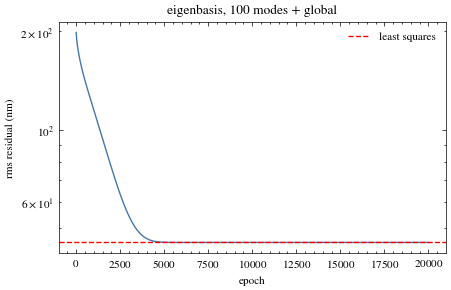

In [6]:
# closed-form weighted least squares, all keys at once: the loop should land on this
sw = np.sqrt(w).reshape(-1)
A = (B_j.reshape(n_basis, -1) / 1e-9 * sw).T  # (n_pix, n_basis)
C_ls = np.linalg.lstsq(A, (target.reshape(len(keys), -1) * sw).T)[0].T
print(f"loop vs least squares: rms {onp.sqrt(float(loss_fn(C_f))):.6f} vs {onp.sqrt(float(loss_fn(C_ls))):.6f} nm, "
      f"max |coefficient difference| {float(np.abs(C_f - C_ls).max()):.2e} nm")

fig, ax = plt.subplots(figsize=(5, 3))
ax.semilogy(onp.sqrt(losses))
ax.axhline(onp.sqrt(float(loss_fn(C_ls))), color="r", ls="--", label="least squares")
ax.set(xlabel="epoch", ylabel="rms residual (nm)", title=f"eigenbasis, {n_eig} modes" + (" + global" if FIT_GLOBAL else ""))
ax.legend()
plt.show()

### Parameter histories
Every coefficient after each step of the loop. Left: the eigenmode coefficients for one key, coloured by mode index, with the
least-squares optimum marked at the right edge. Right: the global terms (if fitted), with their least-squares
values dashed.

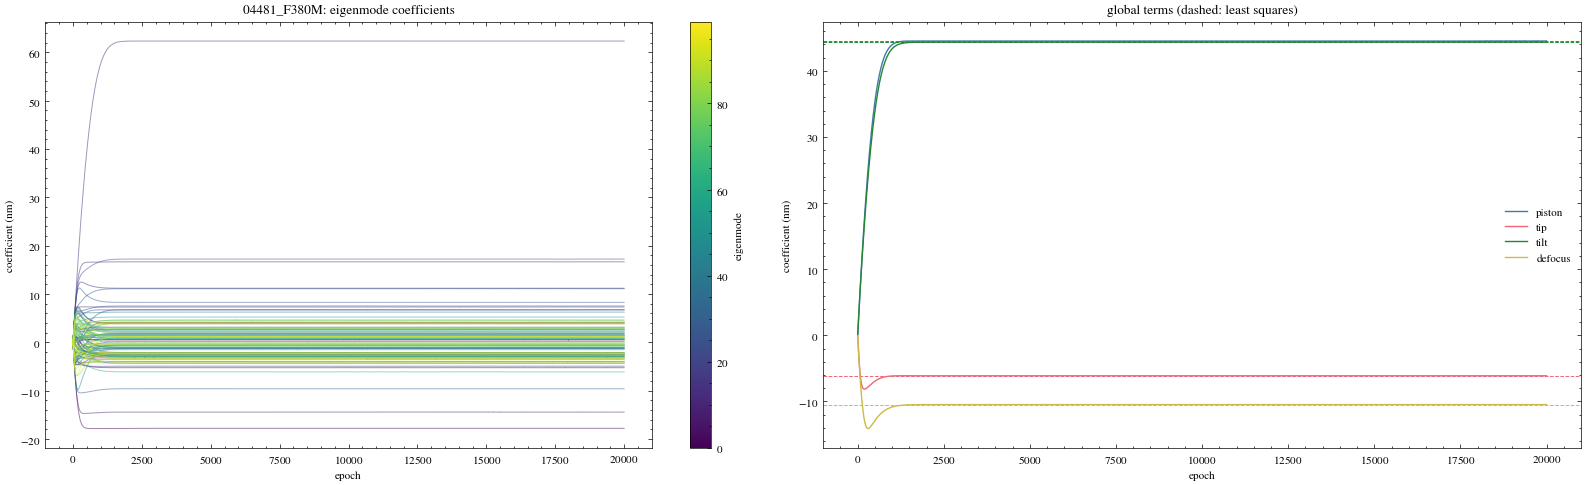

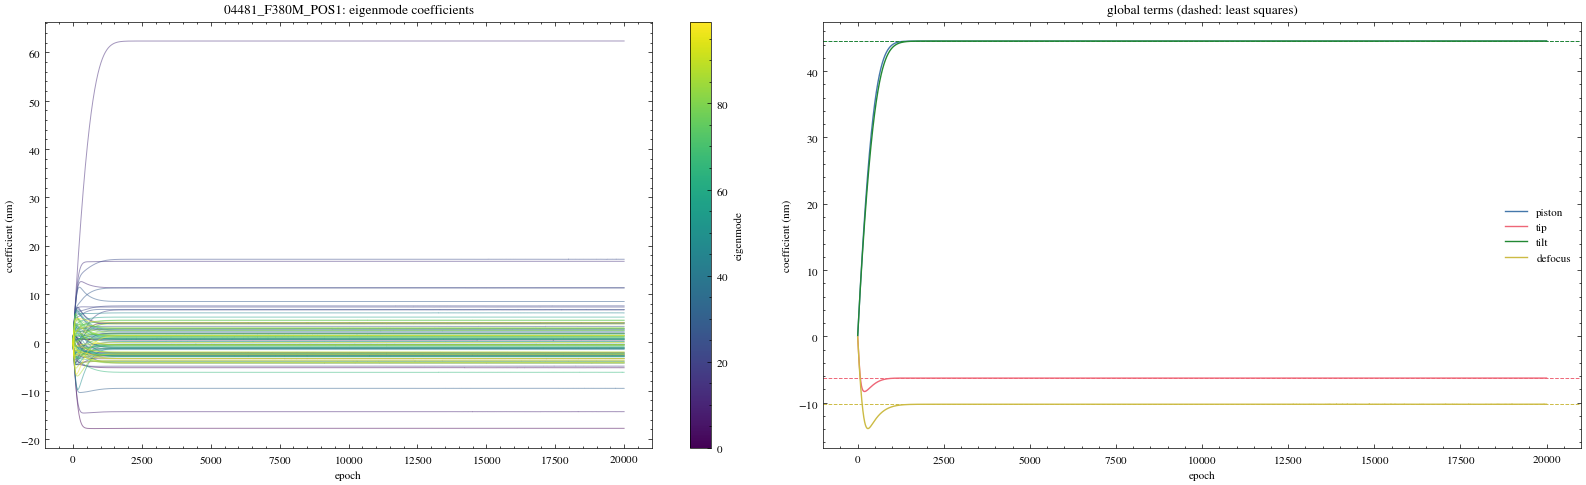

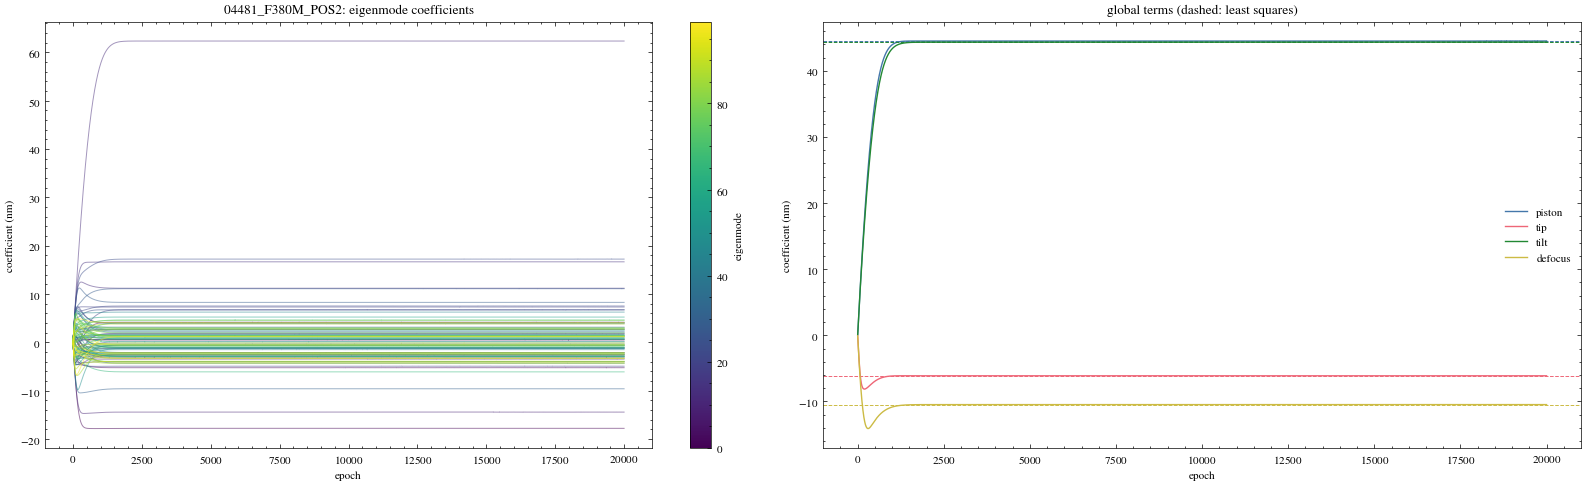

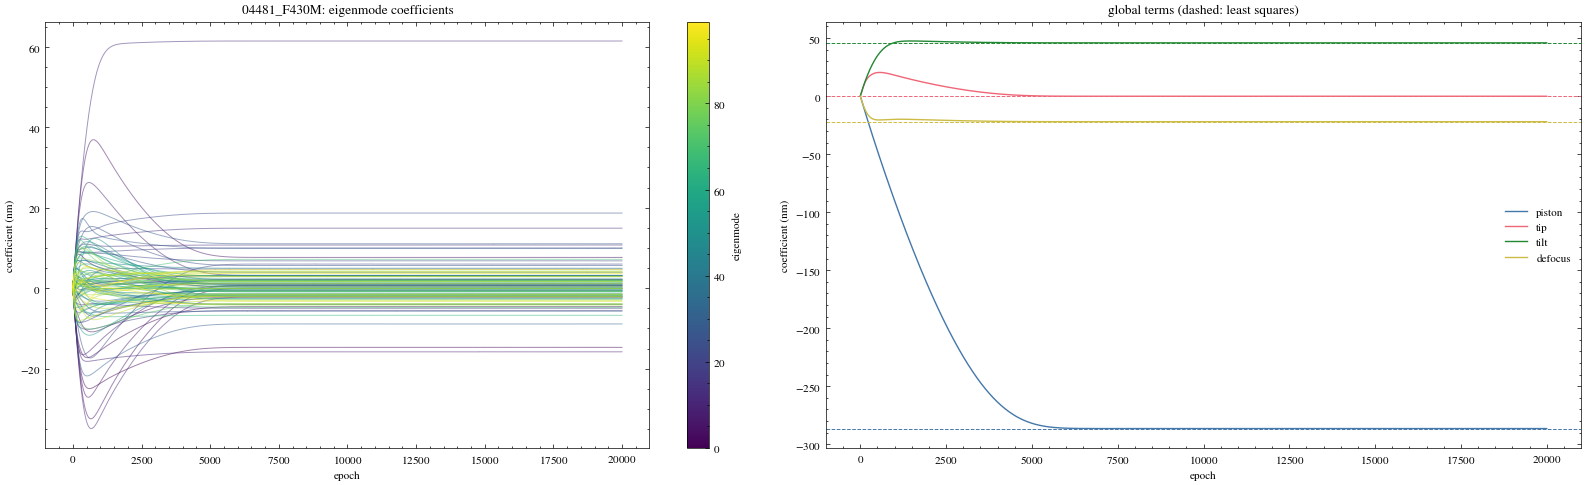

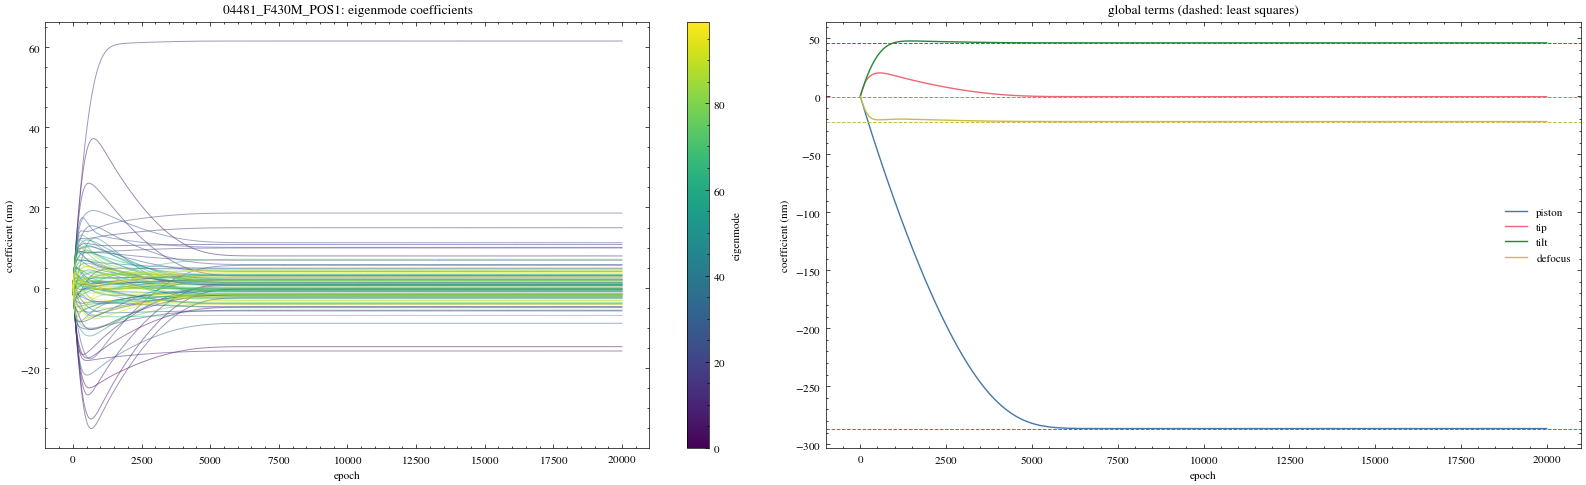

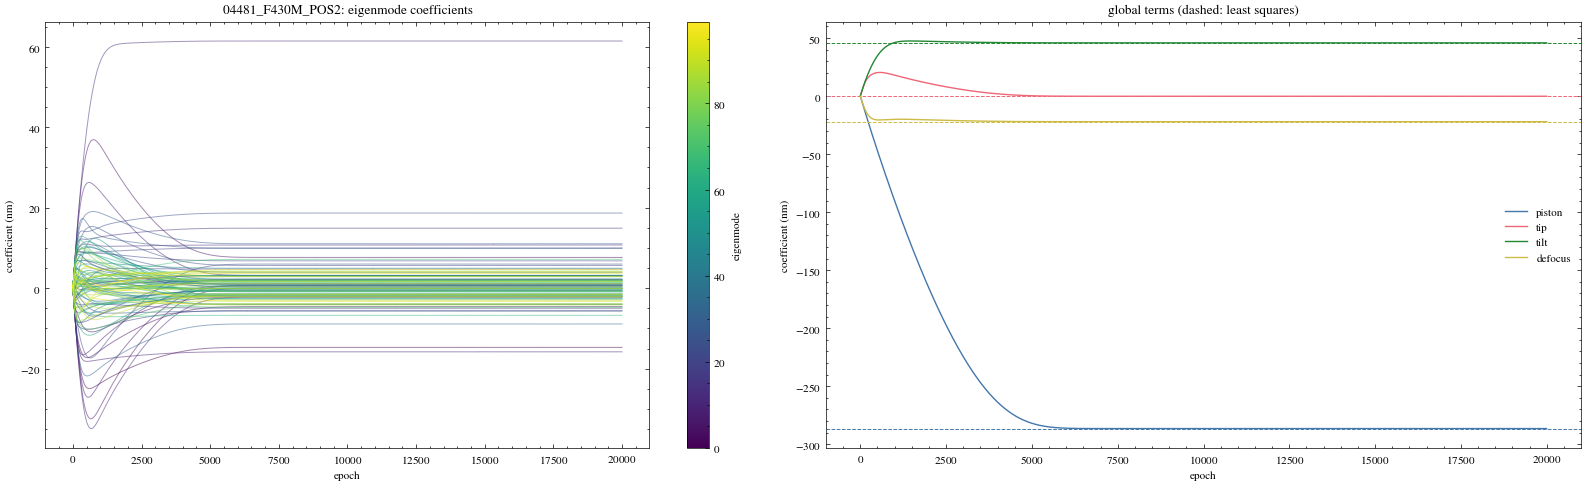

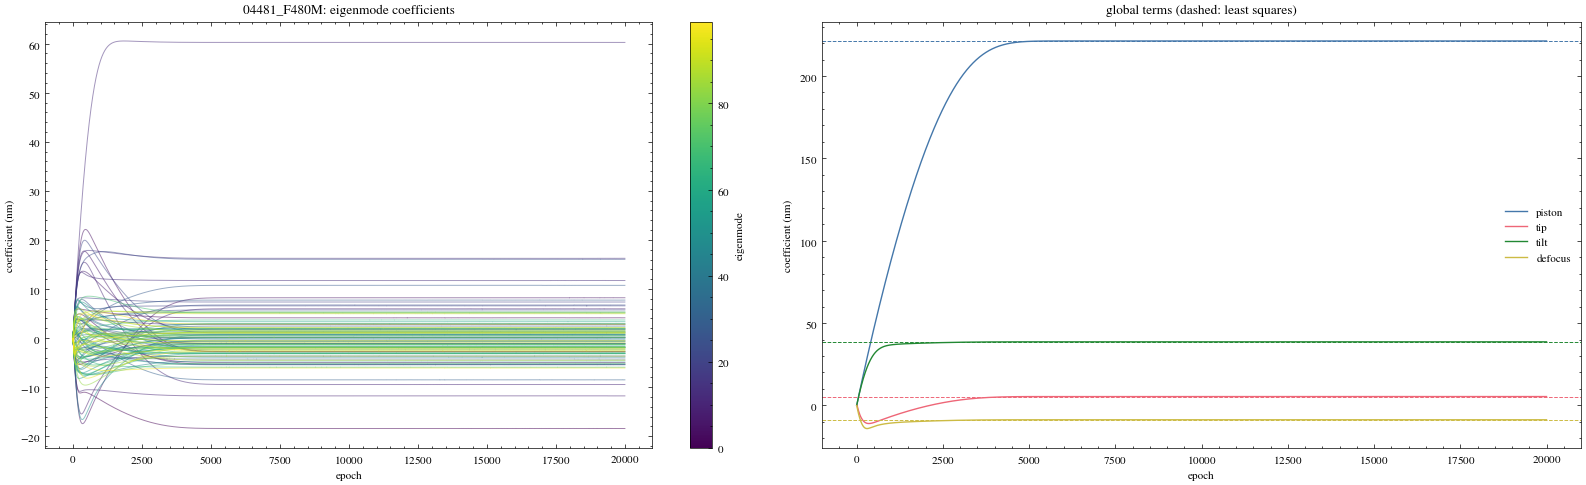

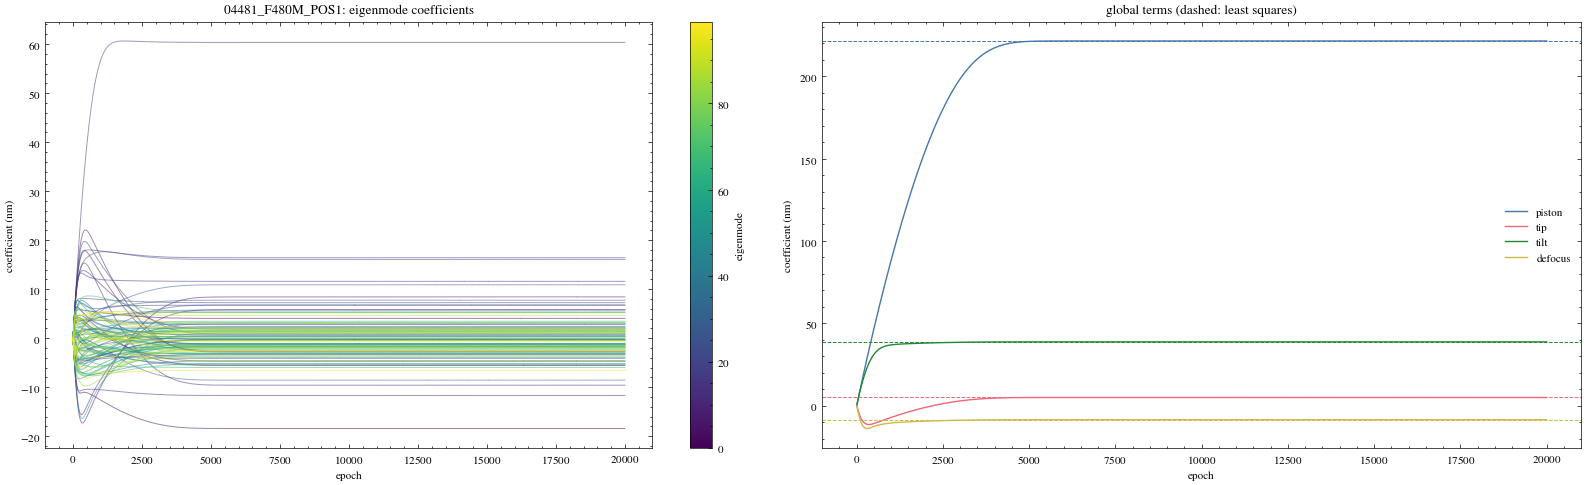

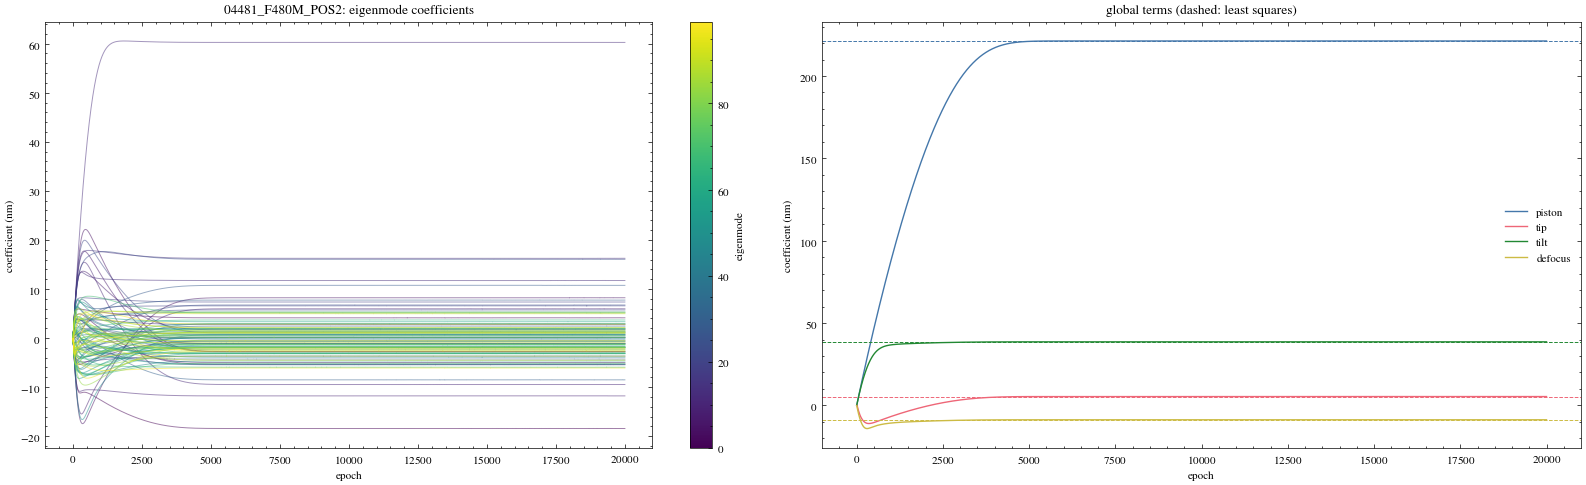

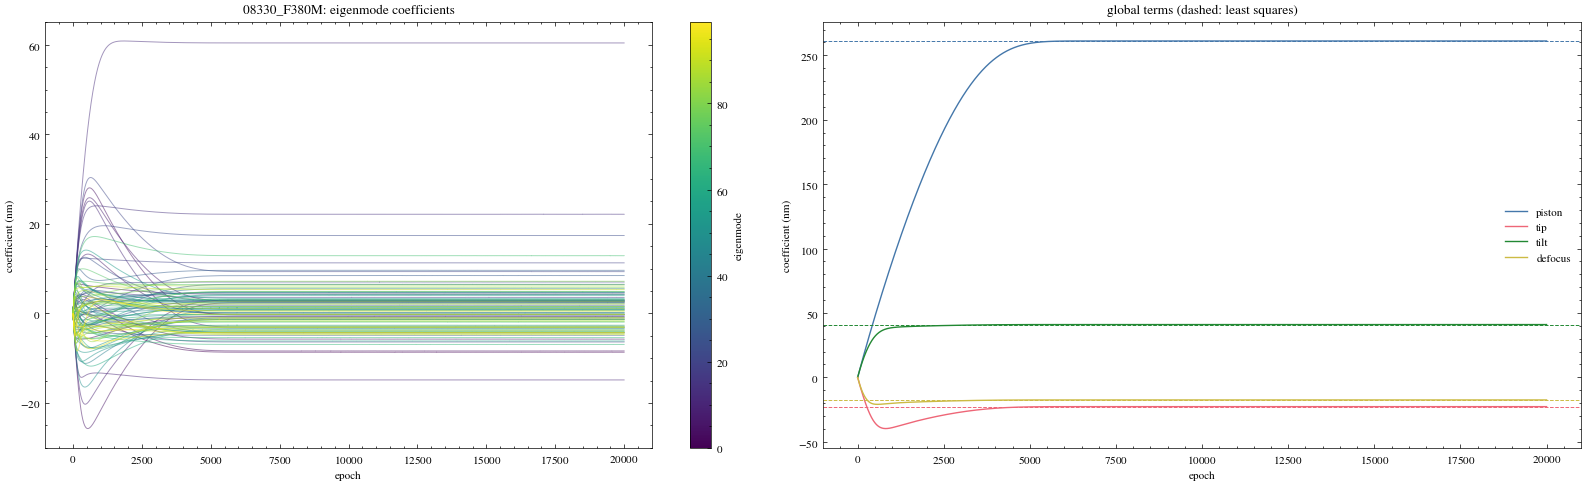

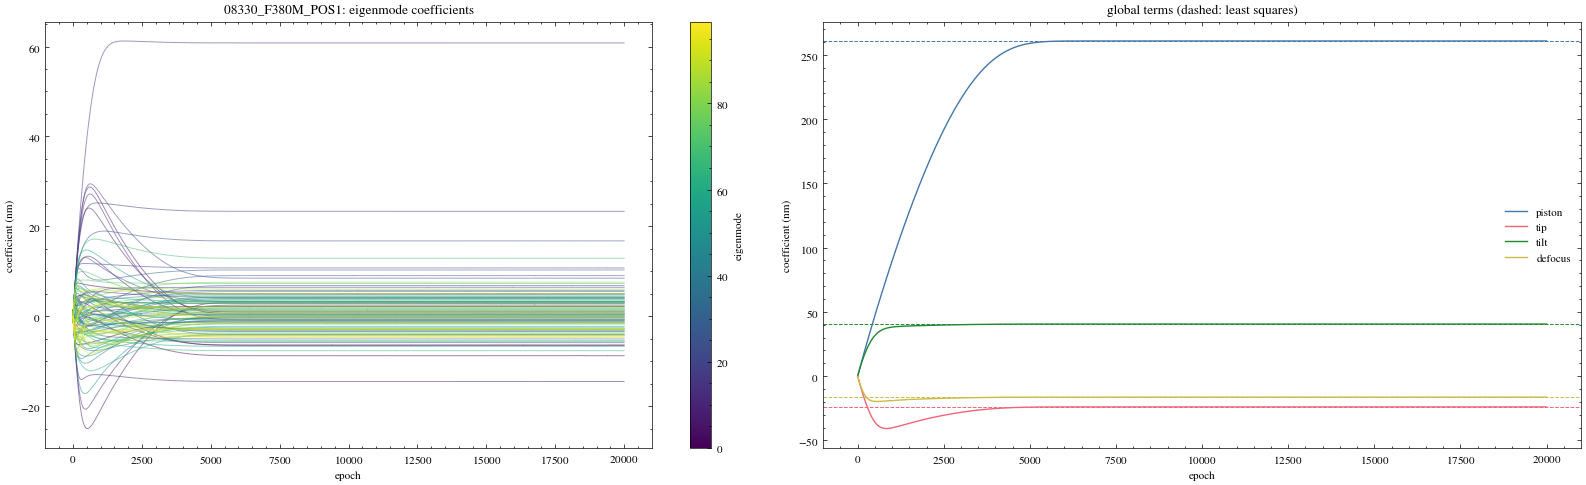

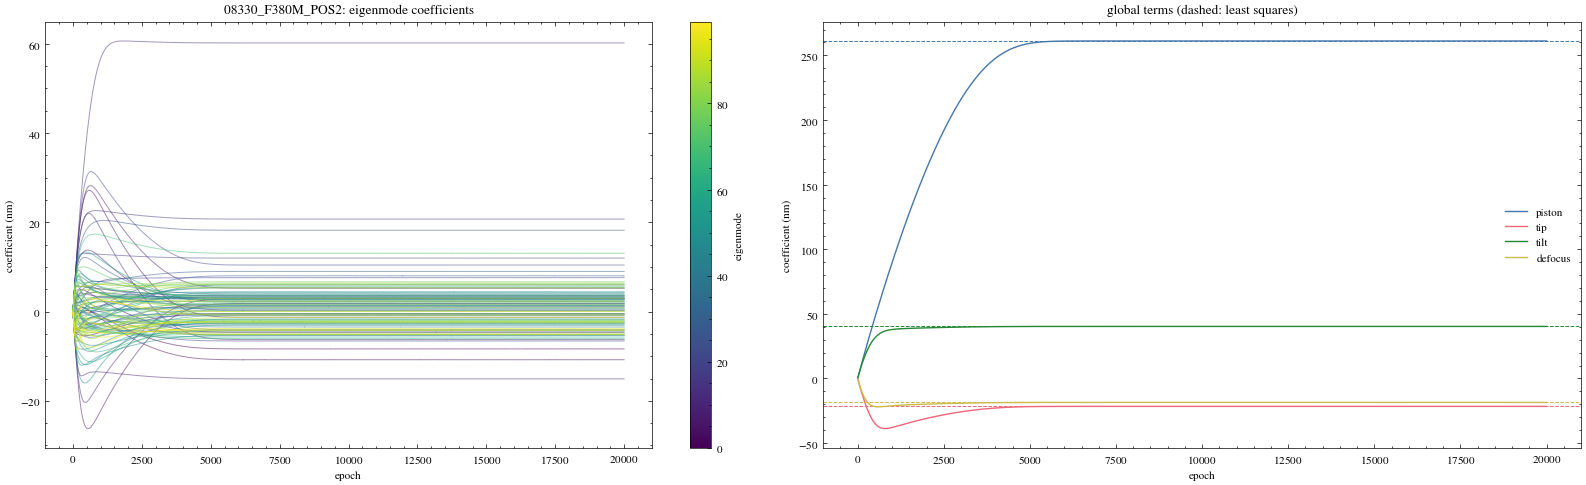

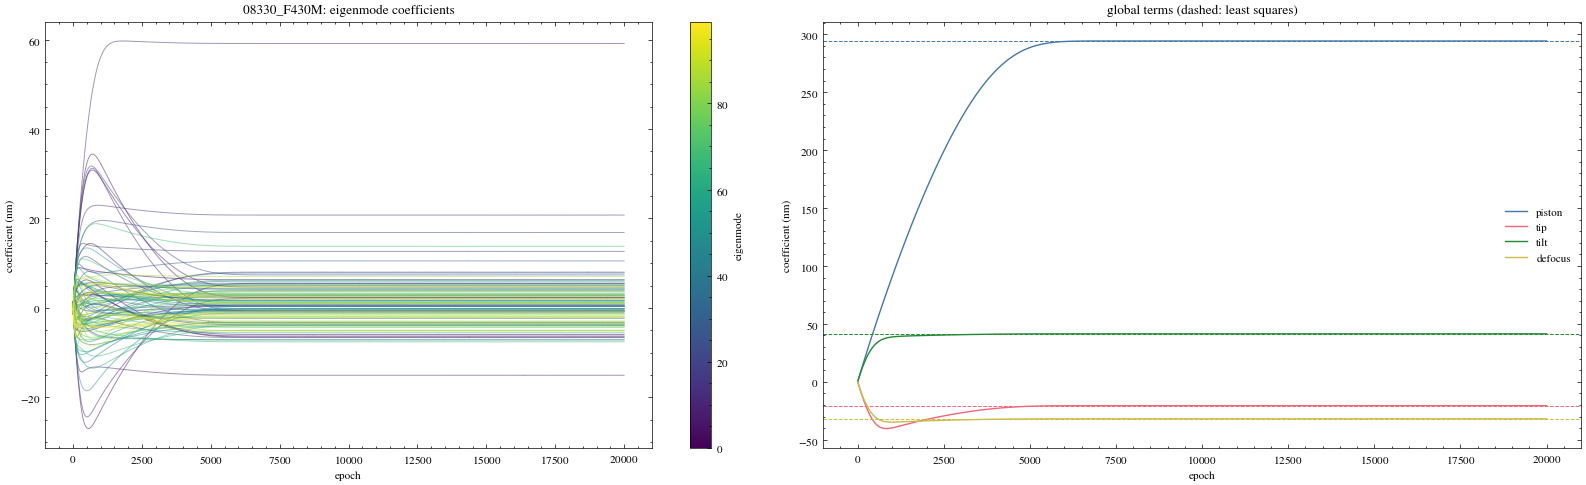

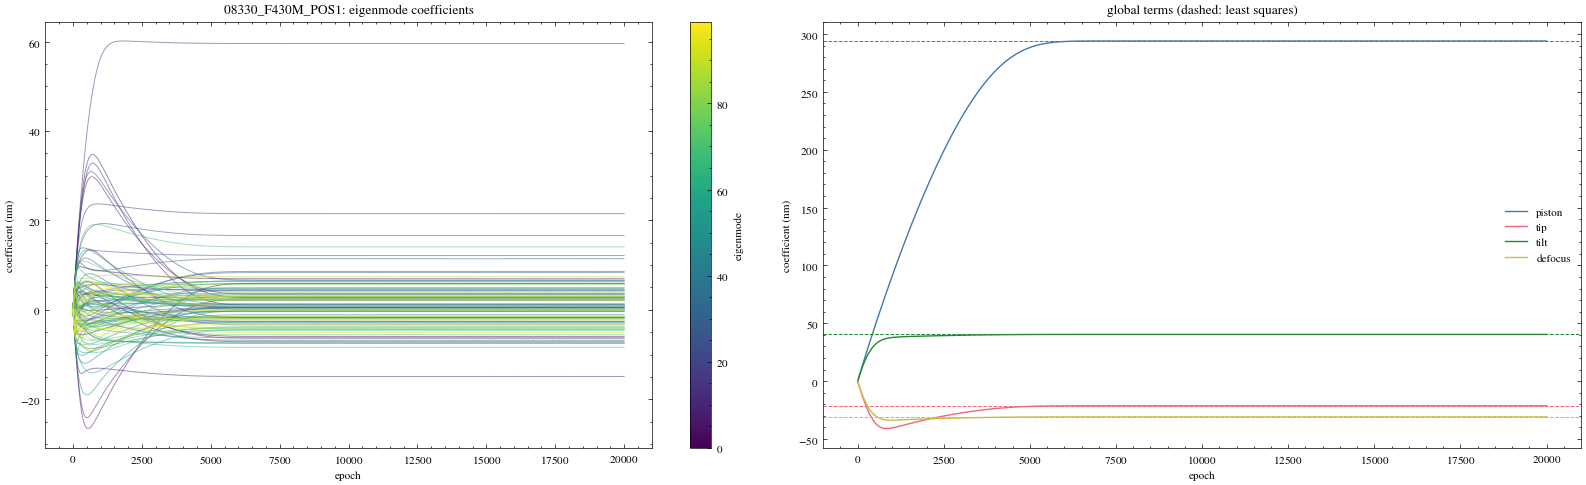

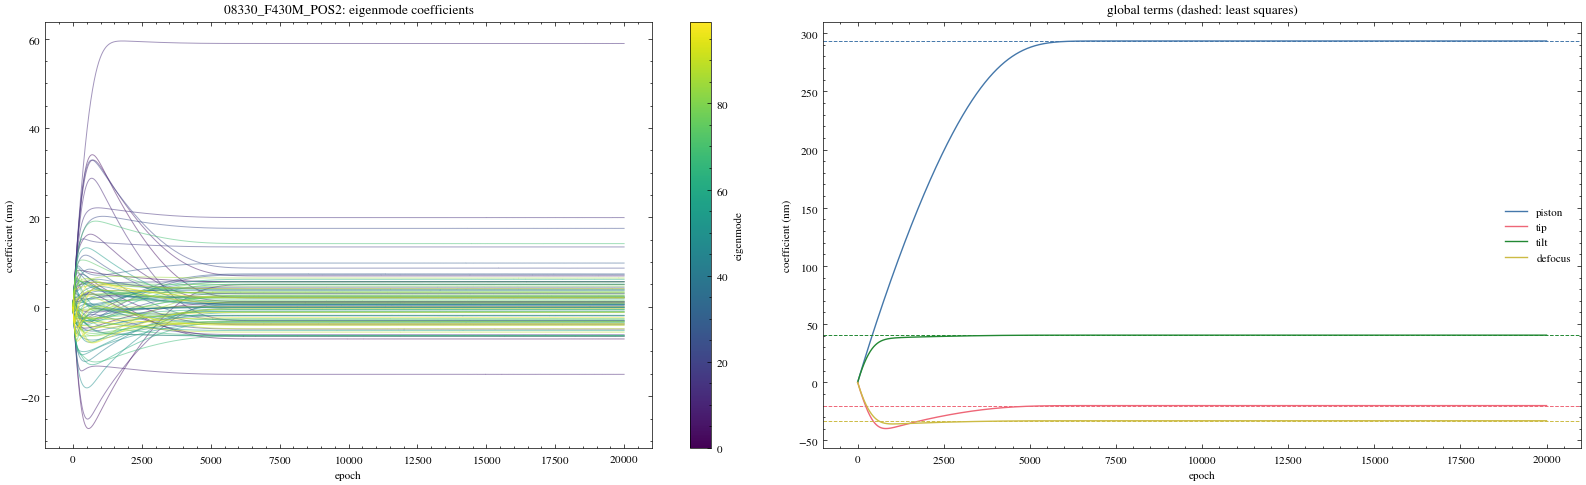

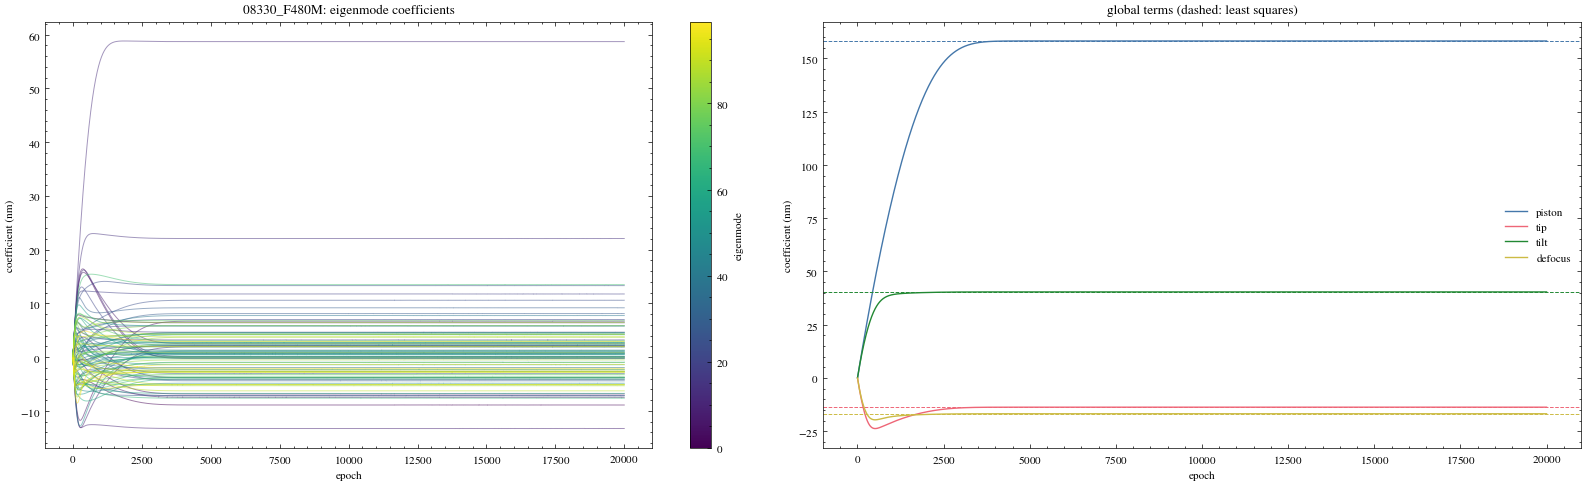

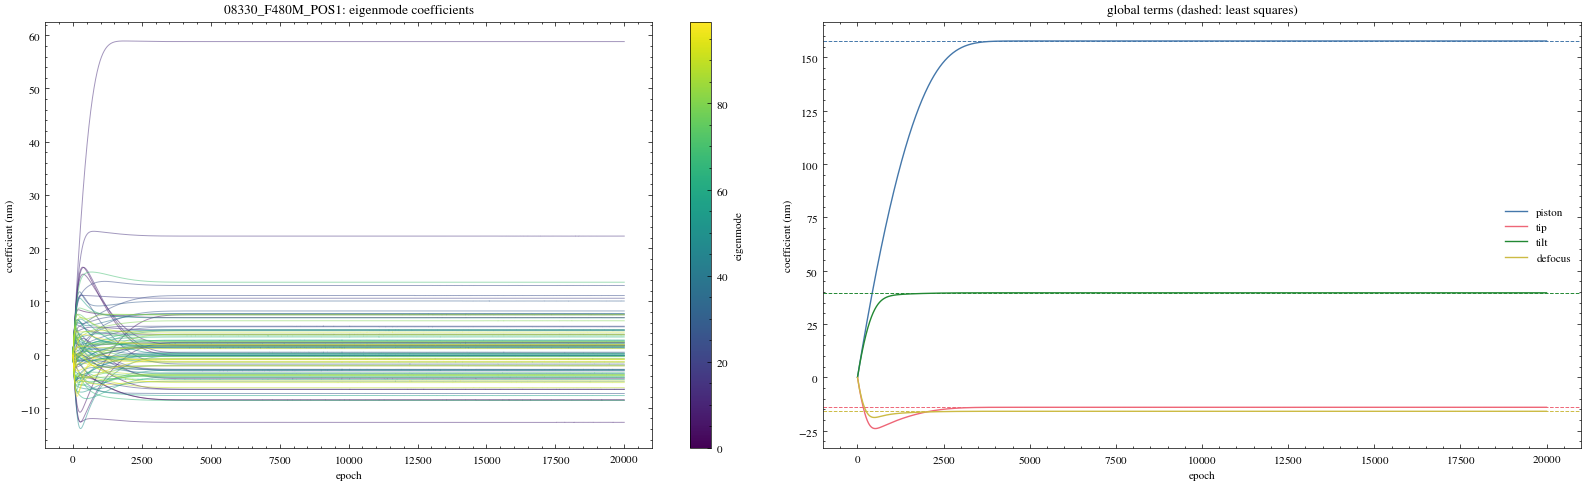

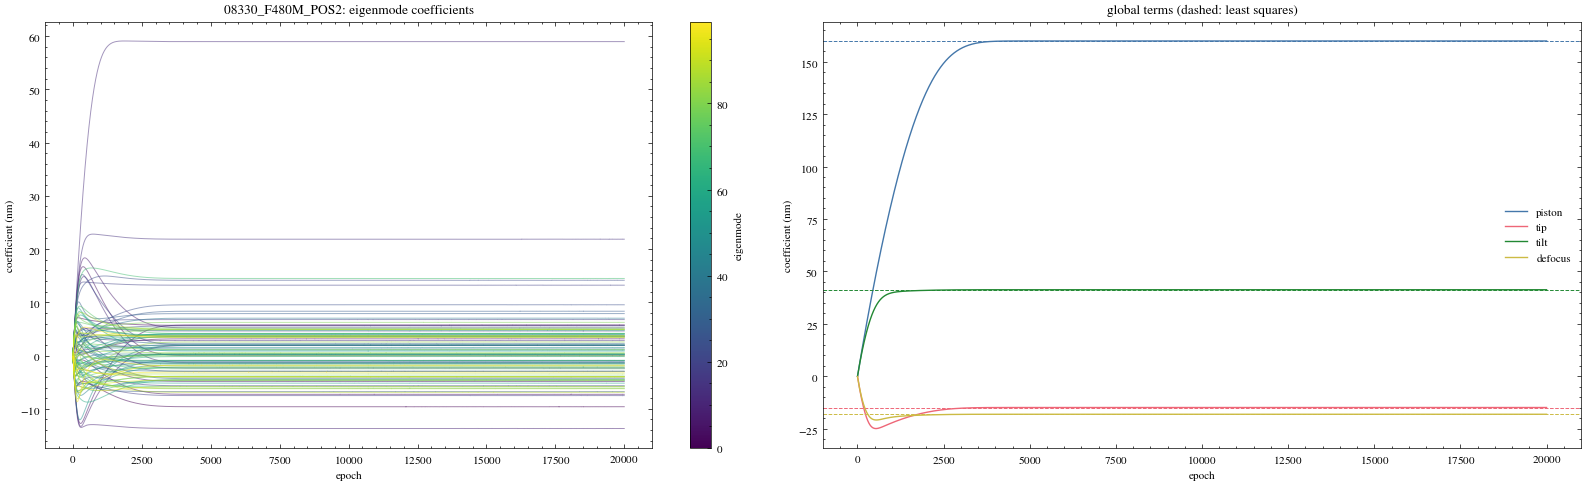

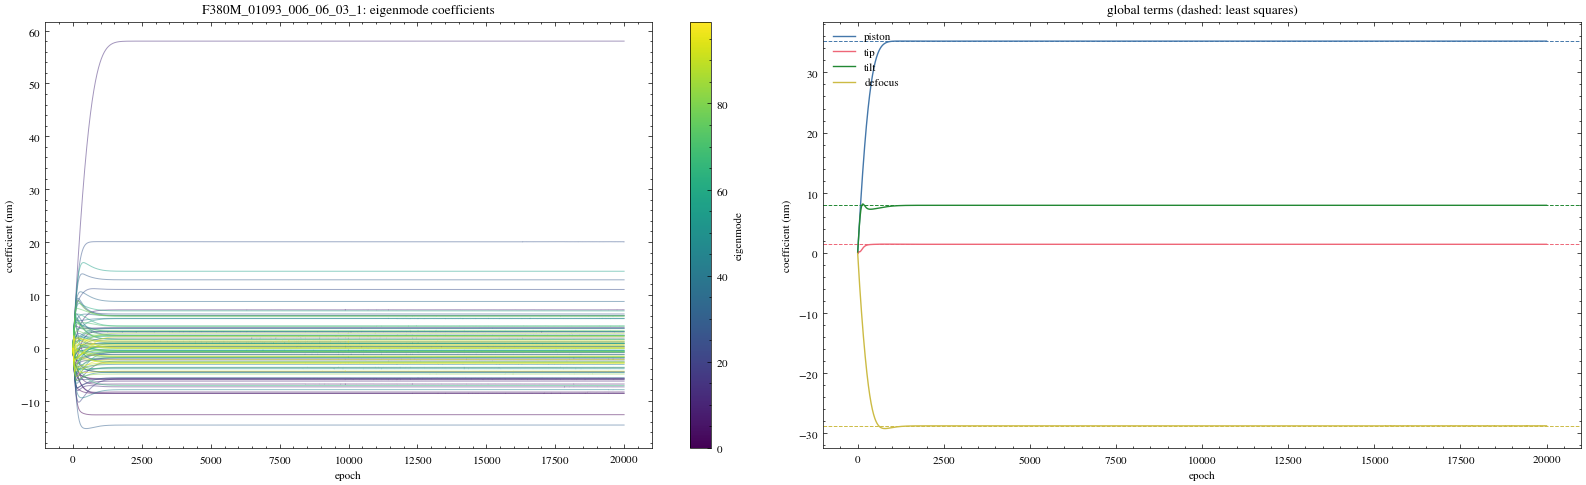

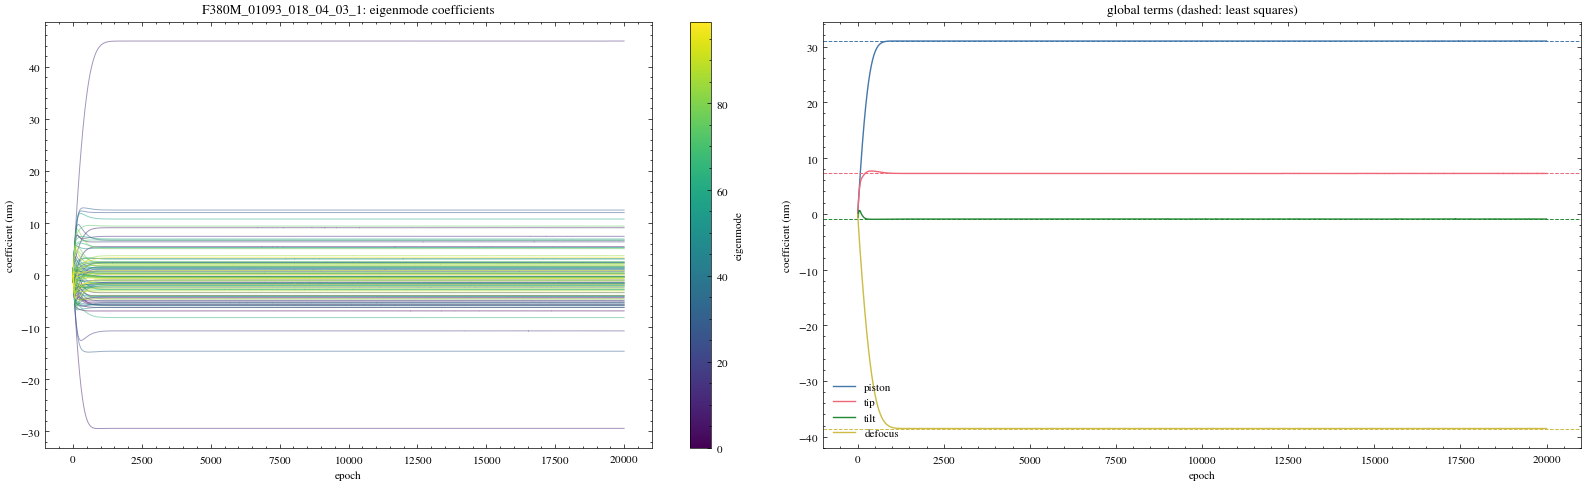

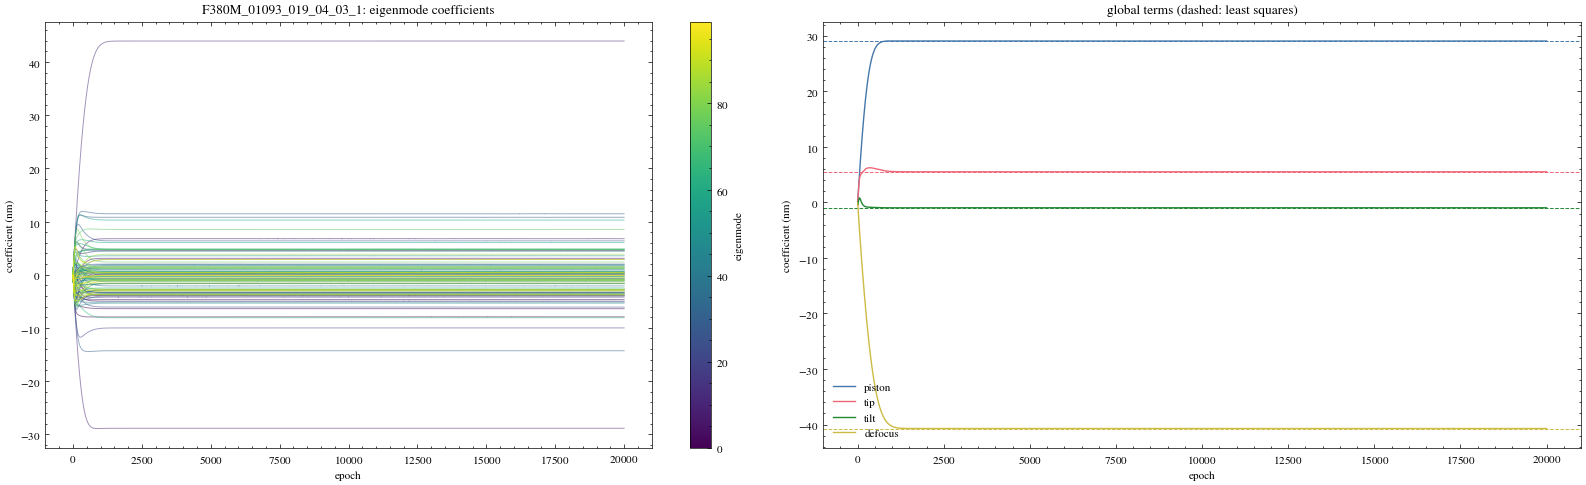

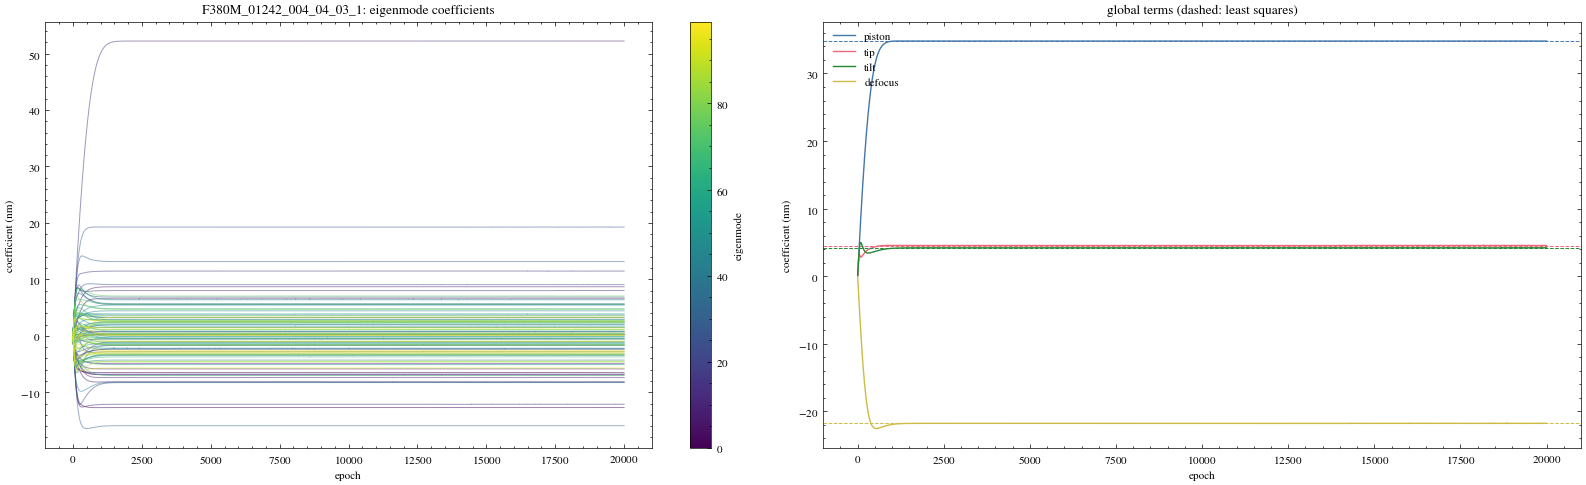

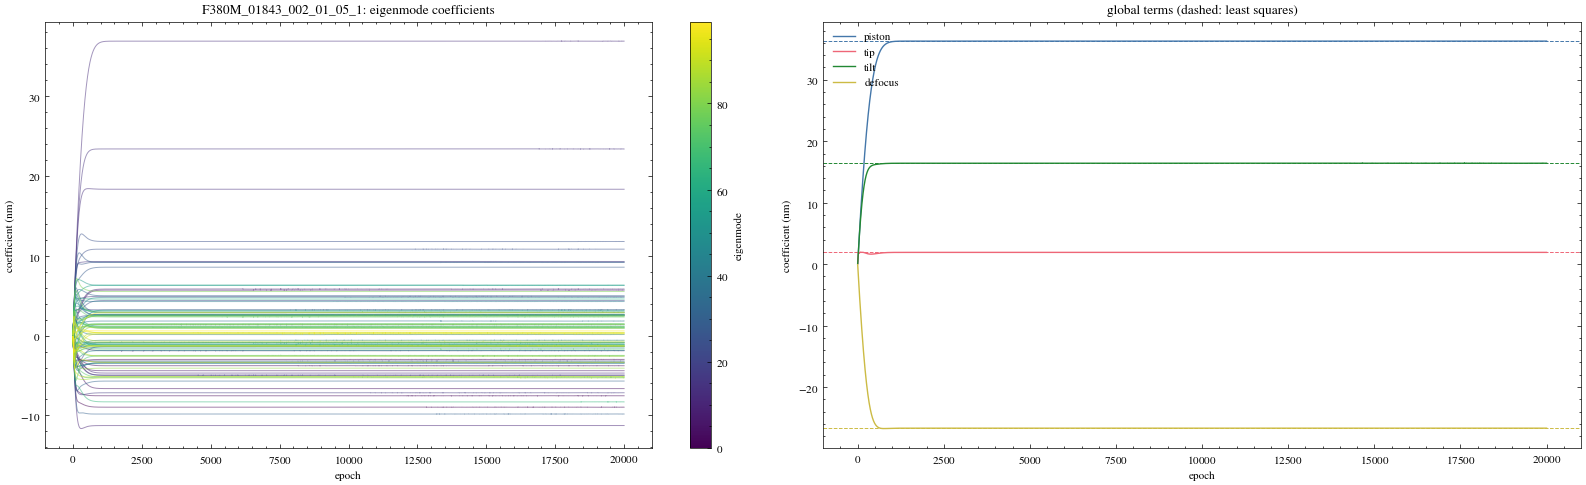

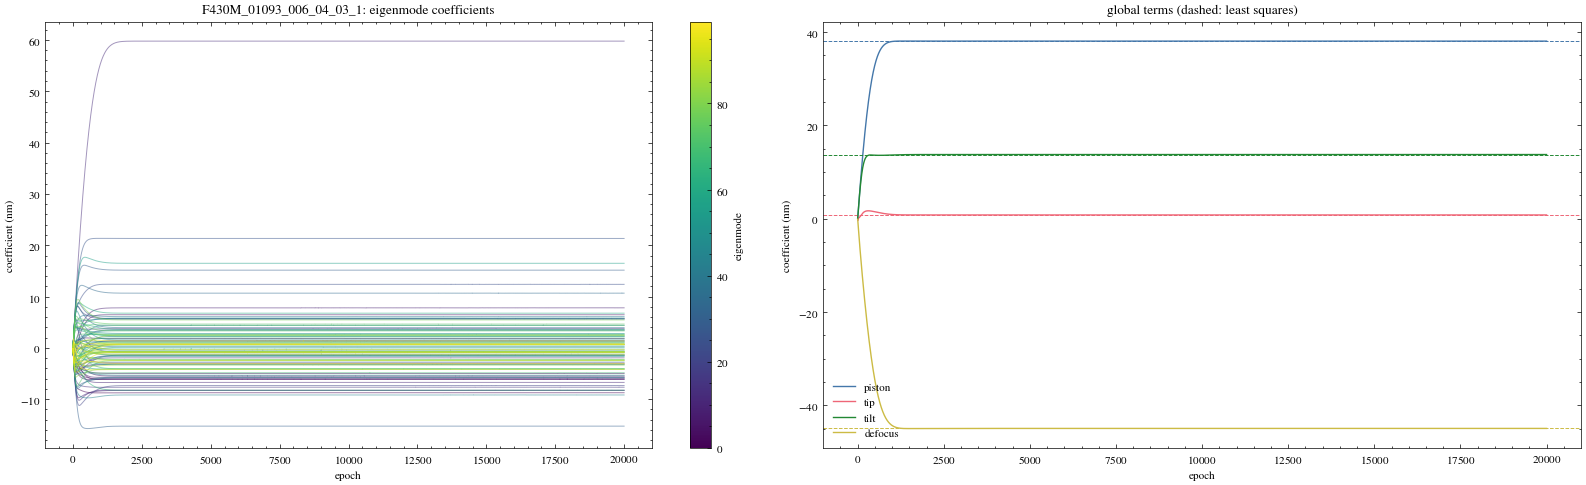

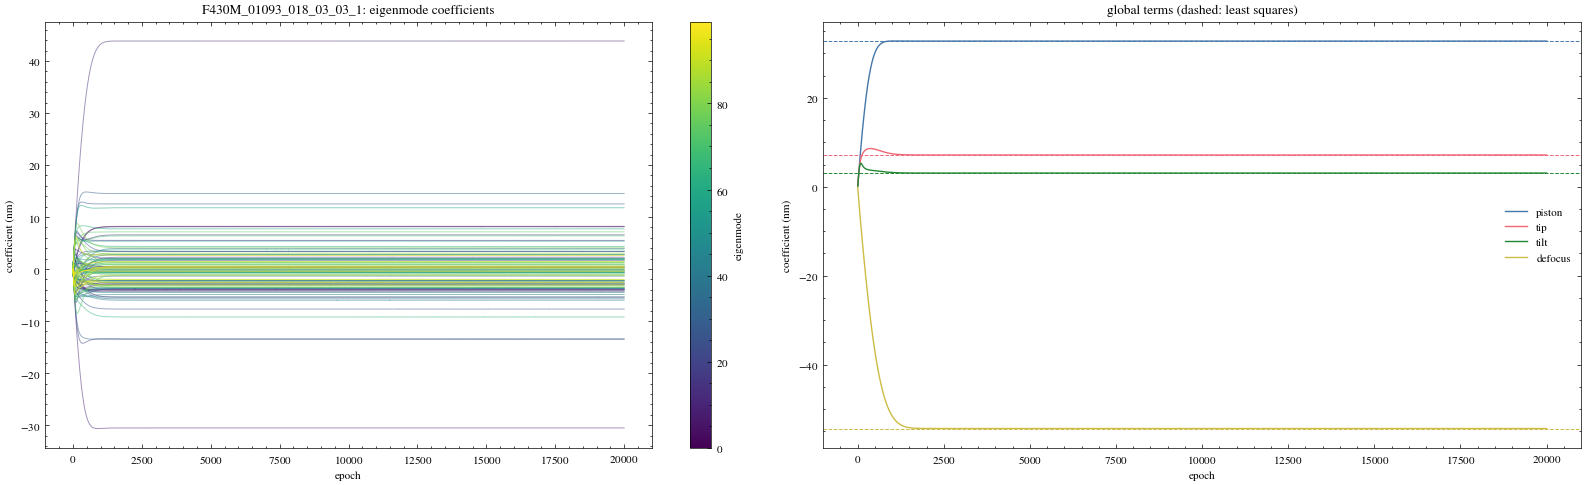

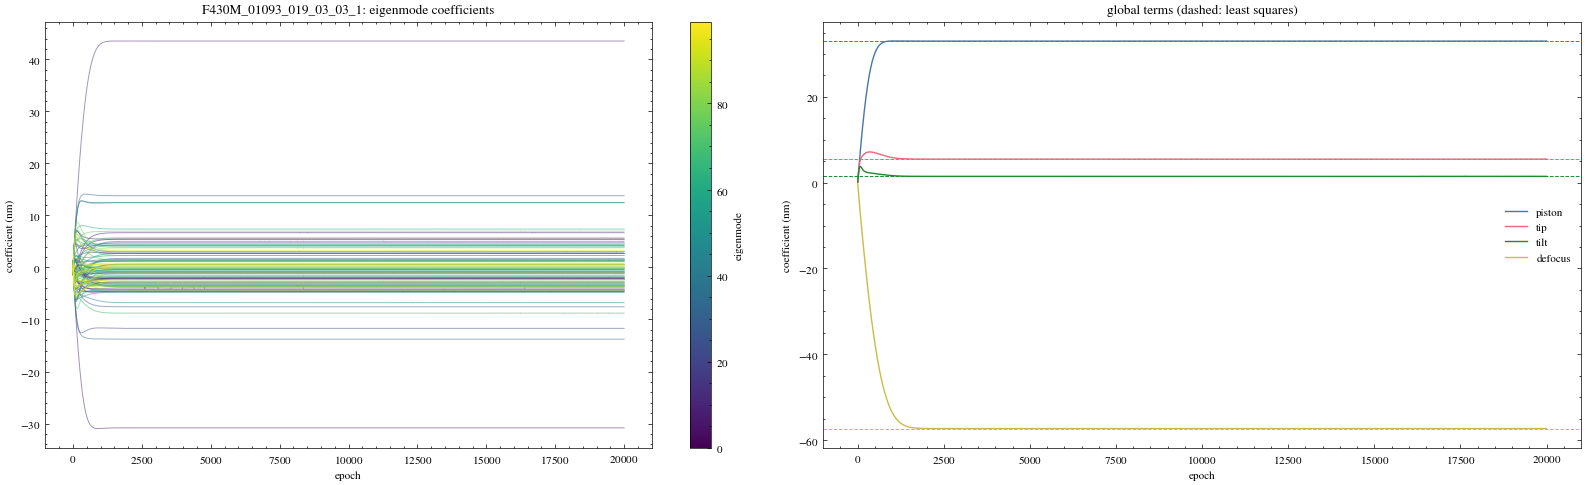

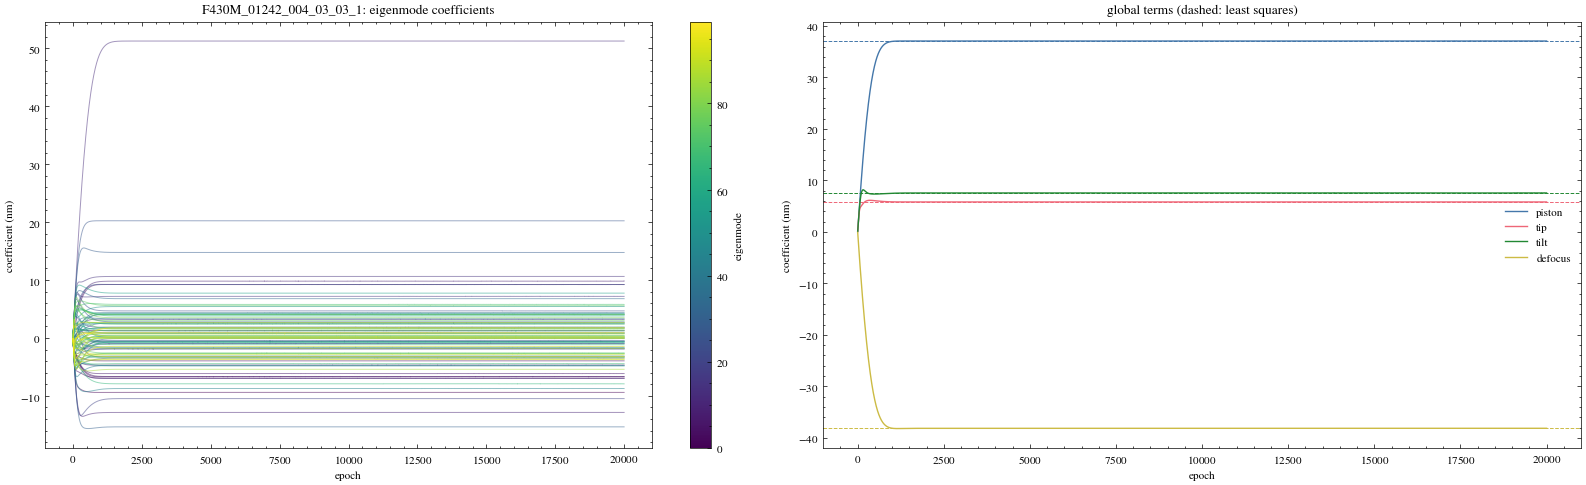

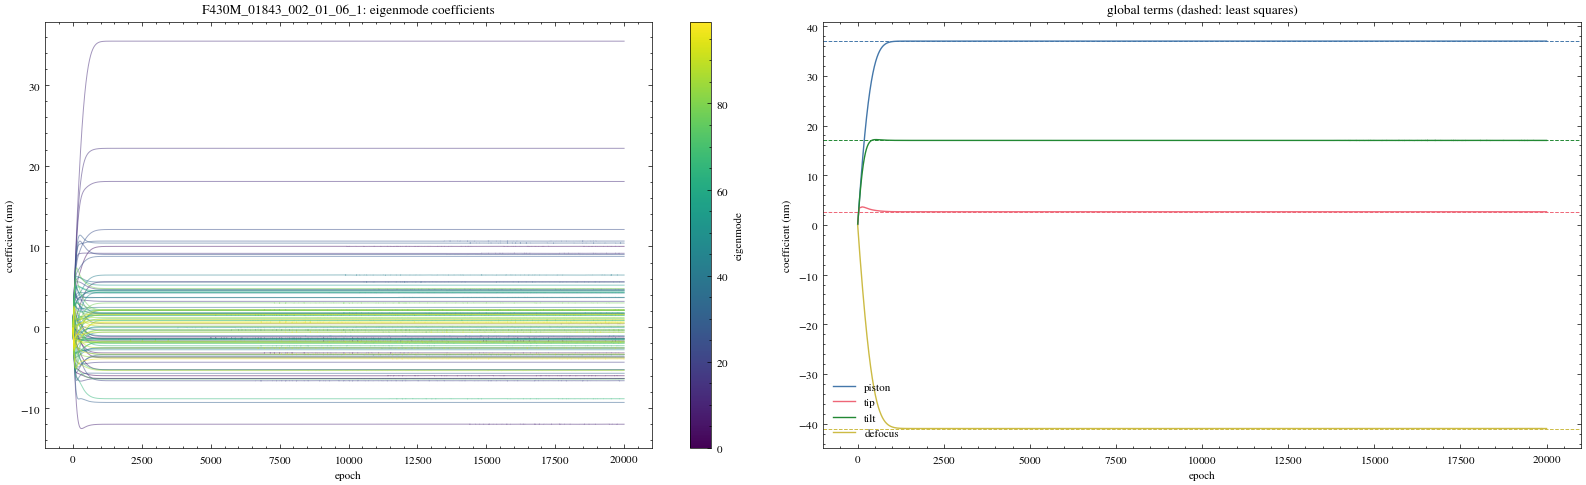

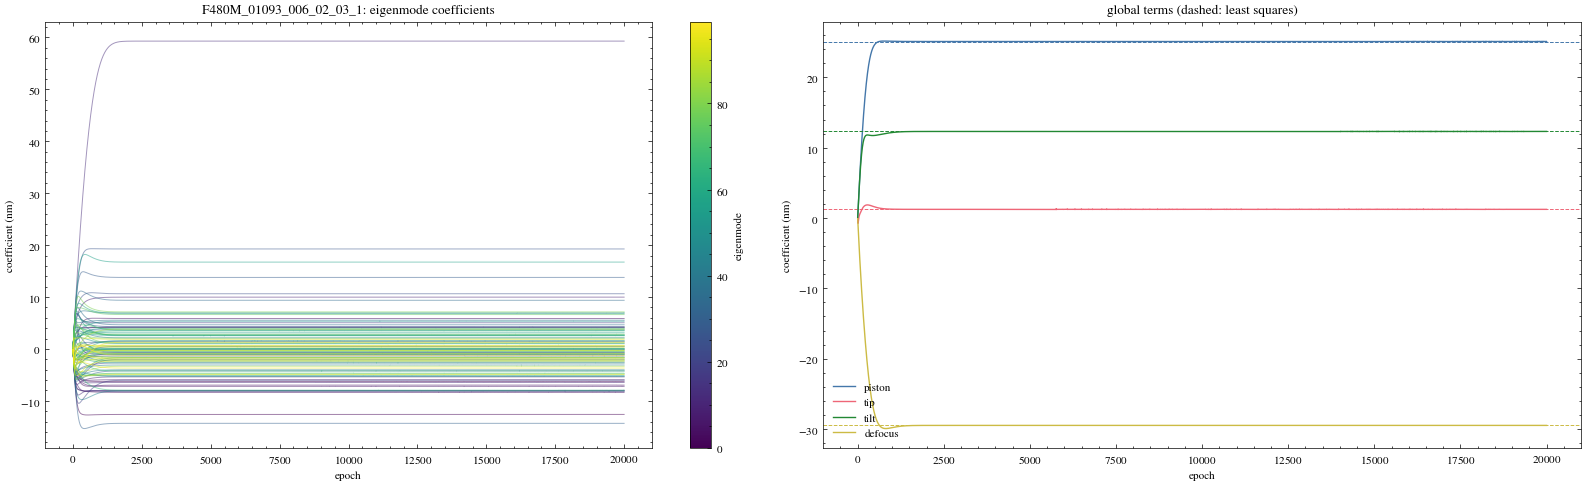

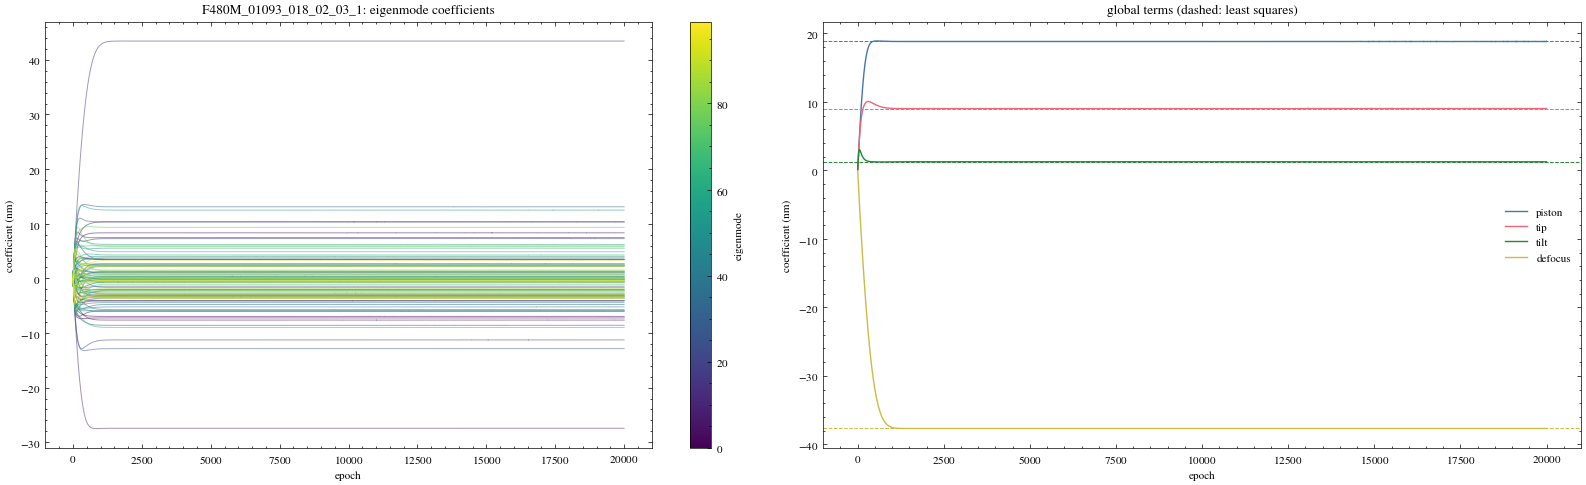

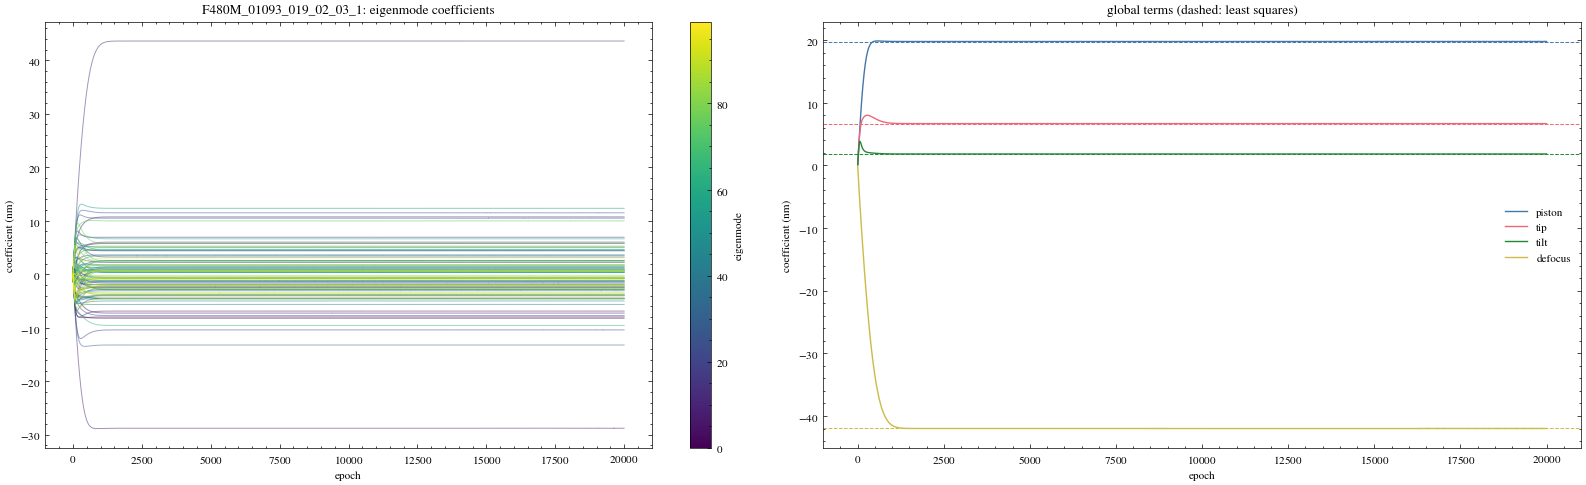

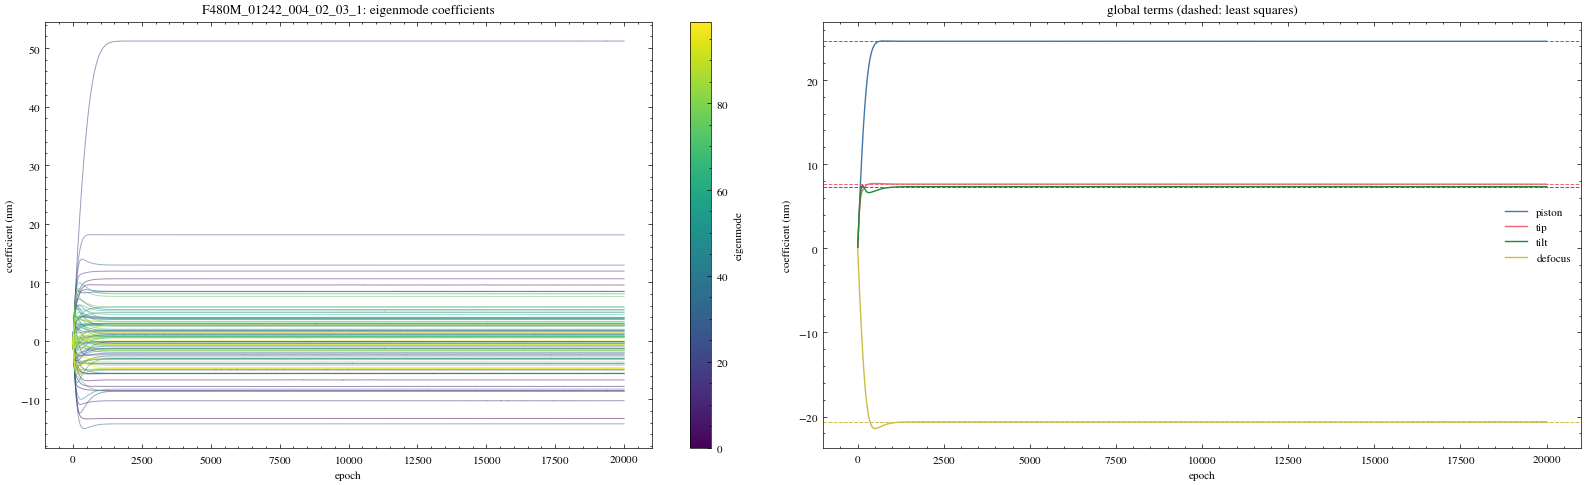

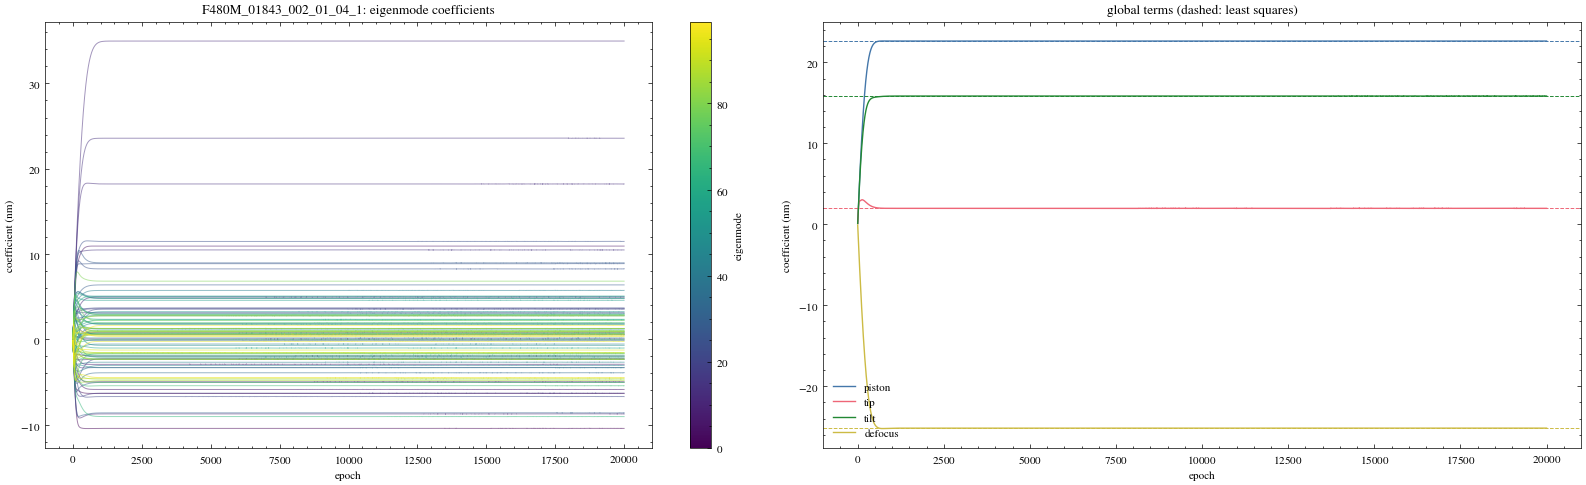

In [7]:
C_ls_np = onp.asarray(C_ls)


def plot_history(key, log_x=False):
    k = keys.index(key)
    ep = onp.arange(1, len(history) + 1)
    ncols = 2 if FIT_GLOBAL else 1
    fig, ax = plt.subplots(1, ncols, figsize=(8 * ncols, 5), squeeze=False)
    ax = ax[0]
    cols = plt.cm.viridis(onp.linspace(0, 1, n_eig))
    for m in range(n_eig):
        ax[0].plot(ep, history[:, k, m], color=cols[m], lw=0.7, alpha=0.5)
    # ax[0].scatter(onp.full(n_eig, ep[-1]), C_ls_np[k, :n_eig], c=cols, s=8, marker="<", zorder=3)
    ax[0].set(xlabel="epoch", ylabel="coefficient (nm)", title=f"{key}: eigenmode coefficients")
    fig.colorbar(plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, n_eig - 1)), ax=ax[0], label="eigenmode")
    if FIT_GLOBAL:
        for g, lab in enumerate(GLOBAL_LABELS):
            line, = ax[1].plot(ep, history[:, k, n_eig + g], label=lab)
            ax[1].axhline(C_ls_np[k, n_eig + g], color=line.get_color(), ls="--", lw=0.7)
        ax[1].set(xlabel="epoch", ylabel="coefficient (nm)", title="global terms (dashed: least squares)")
        ax[1].legend()
    if log_x:
        for a in ax:
            a.set_xscale("log")
    plt.tight_layout()
    plt.show()

for key in keys:
    plot_history(key)


## 4. How good is the match?
Per key: RMS of the Zernike OPD and of the residual over the fitted aperture. Per Noll mode: the fraction of each hole's unit
Zernike that the fitted basis (eigenmodes, plus the global terms if fitted) cannot represent on the fitted aperture, worst hole
and mean over holes — the residual floor comes from these. If `FIT_GLOBAL`, the last panel shows the global terms each key needed.

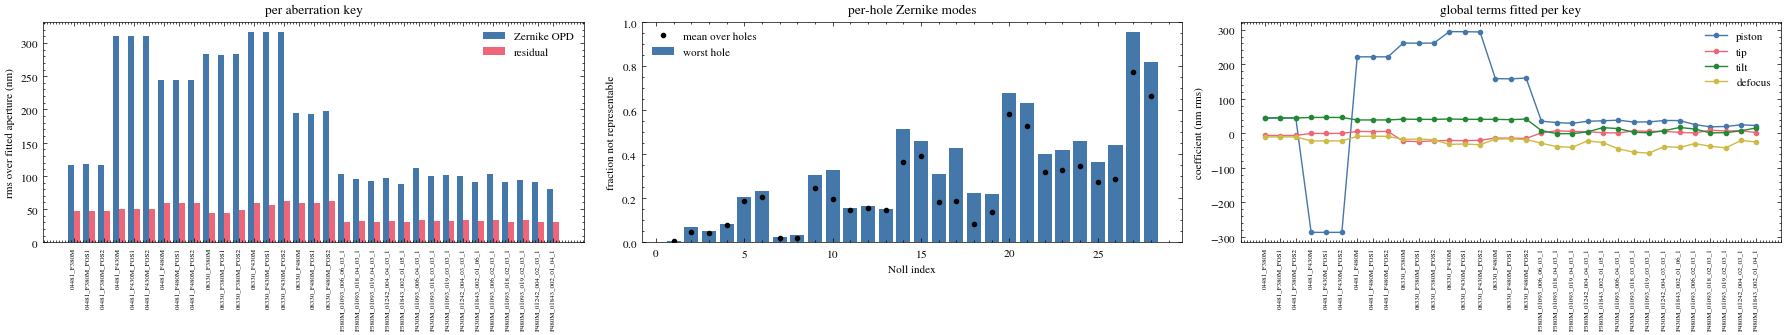

worst key: 08330_F480M_POS2 62.90 nm


In [8]:
res_key = onp.sqrt(onp.asarray(per_key(C_f)).mean(1))
tgt_key = onp.sqrt(onp.asarray(wmse(target)).mean(1))

ncols = 3 if FIT_GLOBAL else 2
fig, ax = plt.subplots(1, ncols, figsize=(6 * ncols, 3.5))
x = onp.arange(len(keys))
ax[0].bar(x - 0.2, tgt_key, 0.4, label="Zernike OPD")
ax[0].bar(x + 0.2, res_key, 0.4, label="residual")
ax[0].set_xticks(x, keys, rotation=90, fontsize=5)
ax[0].set(ylabel="rms over fitted aperture (nm)", title="per aberration key")
ax[0].legend()

# unexplained fraction of each hole's unit Zernike mode, pupil-wide span of the fitted basis
Qa = np.linalg.qr(A)[0]  # (n_pix, n_basis), rows ordered hole by hole
npx = SIZE * SIZE
unexpl = []
for h in range(n_holes):
    Qh = Qa[h * npx : (h + 1) * npx]
    Zw = (basis_z[h].reshape(basis_z.shape[1], -1) / 1e-9 * sw[h * npx : (h + 1) * npx]).T
    unexpl.append(1 - ((Qh.T @ Zw) ** 2).sum(0) / (Zw**2).sum(0))
unexpl = onp.asarray(unexpl)
noll = onp.arange(1, unexpl.shape[1] + 1)
ax[1].bar(noll, unexpl.max(0), label="worst hole")
ax[1].plot(noll, unexpl.mean(0), "k.", label="mean over holes")
ax[1].set(xlabel="Noll index", ylabel="fraction not representable", ylim=(0, 1), title="per-hole Zernike modes")
ax[1].legend()

if FIT_GLOBAL:
    Cg = onp.asarray(C_f[:, n_eig:])
    for j, lab in enumerate(GLOBAL_LABELS):
        ax[2].plot(x, Cg[:, j], "o-", ms=3, label=lab)
    ax[2].set_xticks(x, keys, rotation=90, fontsize=5)
    ax[2].set(ylabel="coefficient (nm rms)", title="global terms fitted per key")
    ax[2].legend()
plt.tight_layout()
plt.show()
print("worst key:", keys[int(res_key.argmax())], f"{res_key.max():.2f} nm")

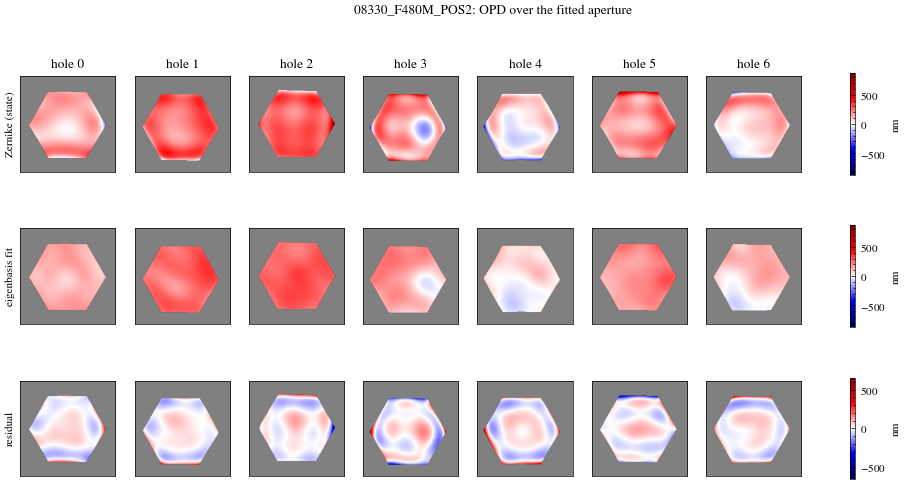

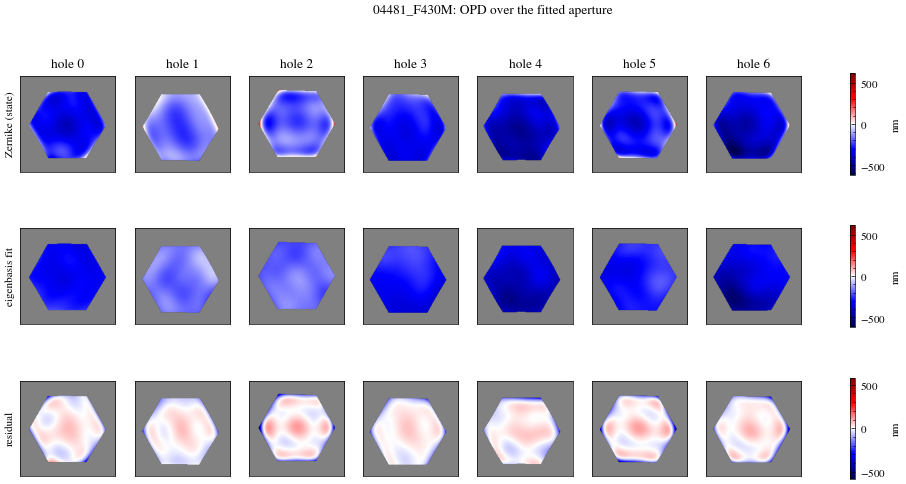

In [9]:
def show_key(key, hole_mask=mask):
    k = keys.index(key)
    fit = onp.asarray(opd(B_j, C_f[k]))
    tgt = onp.asarray(target[k])
    m = onp.asarray(hole_mask) > 0.5
    rows = {"Zernike (state)": tgt, "eigenbasis fit": fit, "residual": fit - tgt}
    v = onp.abs(onp.where(m, tgt, 0)).max()
    fig, ax = plt.subplots(3, n_holes, figsize=(1.8 * n_holes, 5.6))
    for r, (name, arr) in enumerate(rows.items()):
        vr = v if r < 2 else onp.abs(onp.where(m, arr, 0)).max()
        for h in range(n_holes):
            im = ax[r, h].imshow(onp.where(m[h], arr[h], onp.nan), cmap=seismic, vmin=-vr, vmax=vr)
            ax[r, h].set(xticks=[], yticks=[])
            if r == 0:
                ax[r, h].set_title(f"hole {h}")
        ax[r, 0].set_ylabel(name)
        fig.colorbar(im, ax=ax[r], shrink=0.8, label="nm")
    fig.suptitle(f"{key}: OPD over the fitted aperture")
    plt.show()


show_key(keys[int(res_key.argmax())])
show_key("04481_F430M")

All keys: residual RMS per key and hole, then the residual OPD for every key (rows) and hole (columns) on one shared
colour scale (clipped at the 99.5th percentile over all apertures, so a few edge pixels don't wash it out).

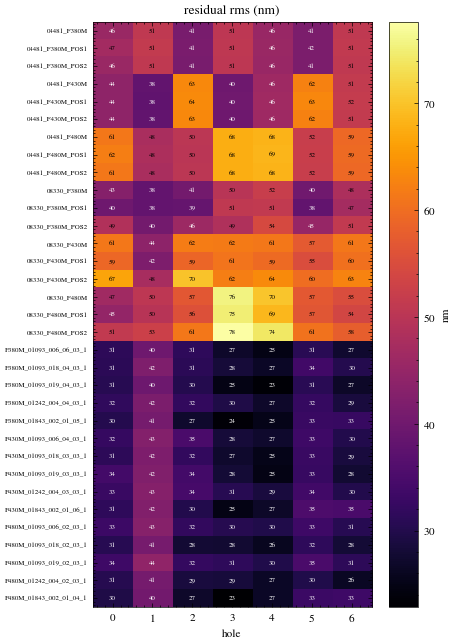

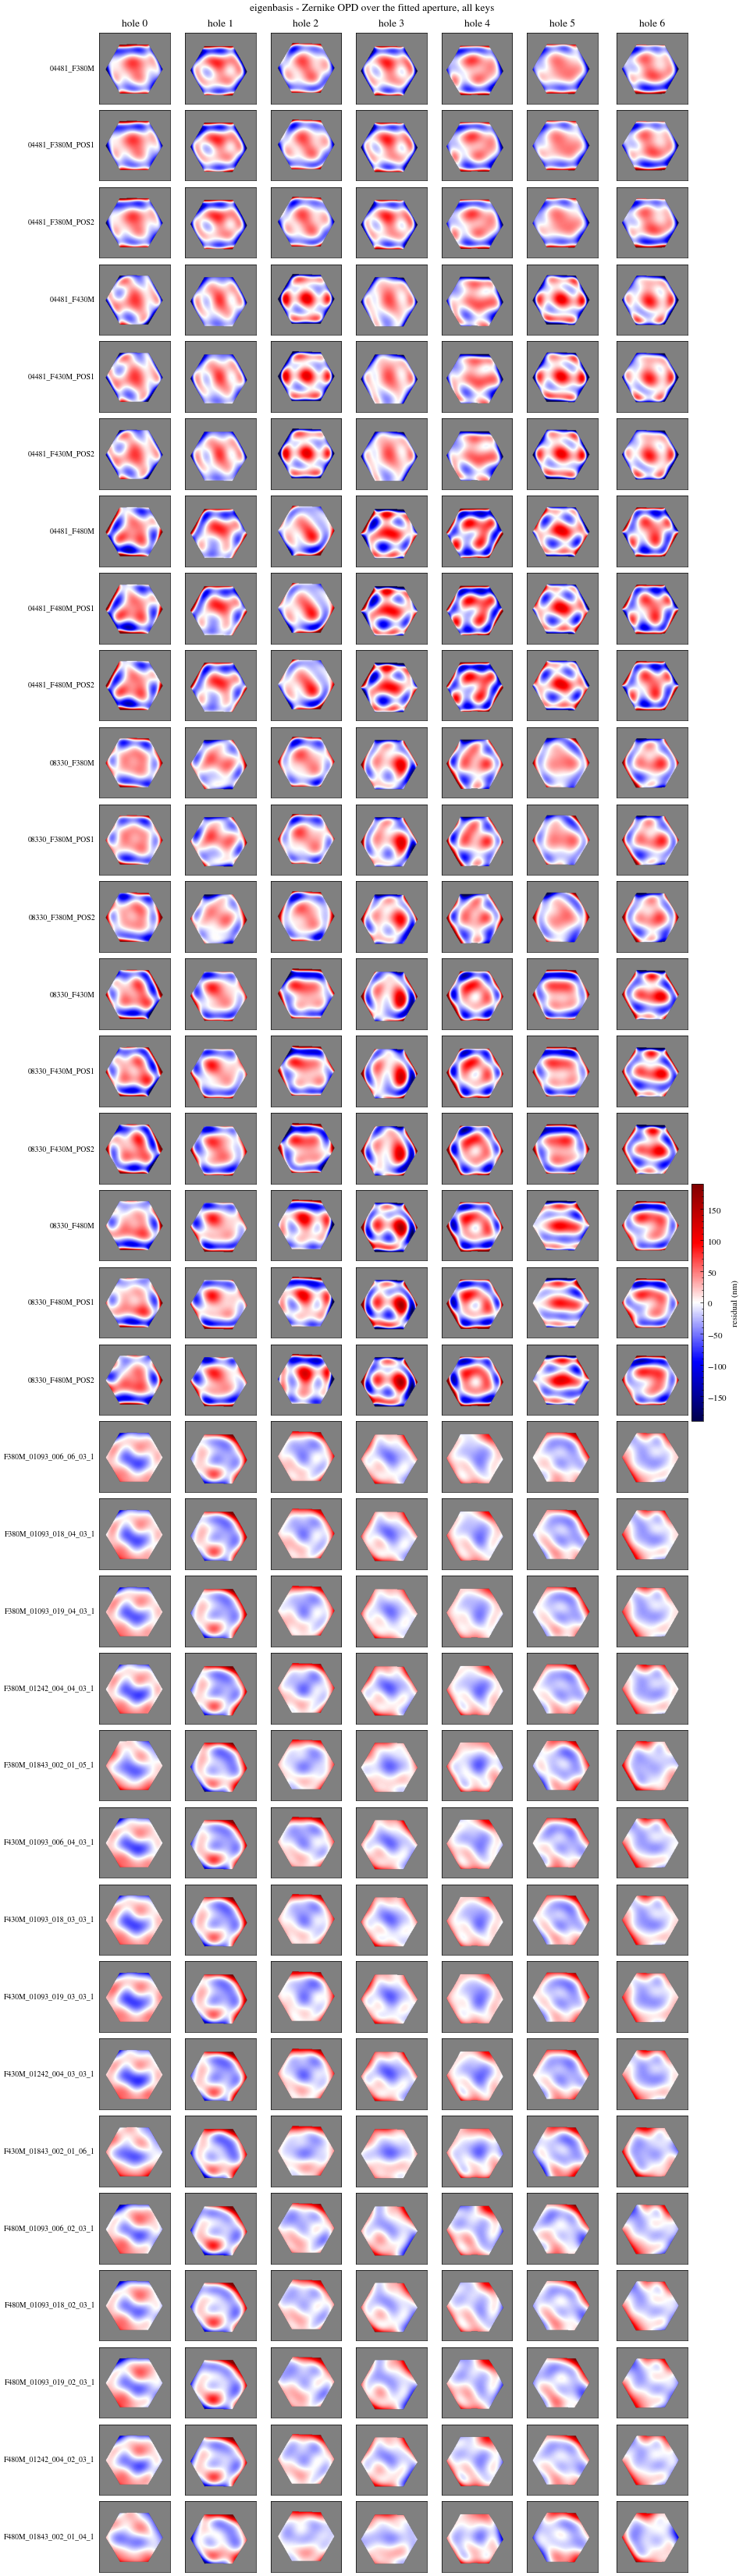

In [10]:
res_kh = onp.sqrt(onp.asarray(per_key(C_f)))  # (K, n_holes) nm

fig, ax = plt.subplots(figsize=(4.5, 0.2 * len(keys) + 1))
im = ax.imshow(res_kh, cmap="inferno", aspect="auto", origin="upper")
for (k, h), v in onp.ndenumerate(res_kh):
    ax.text(h, k, f"{v:.0f}", ha="center", va="center", fontsize=5, color="w" if v < 0.6 * res_kh.max() else "k")
ax.set_yticks(range(len(keys)), keys, fontsize=5)
ax.set(xticks=range(n_holes), xlabel="hole", title="residual rms (nm)")
fig.colorbar(im, ax=ax, label="nm")
plt.show()

resid = onp.asarray(vmap(lambda c: opd(B_j, c))(C_f) - target)  # (K, n_holes, S, S)
m = onp.asarray(mask) > 0.5
v = onp.percentile(onp.abs(resid[:, m]), 99.5)
fig, ax = plt.subplots(len(keys), n_holes, figsize=(1.0 * n_holes + 2.5, 1.0 * len(keys)), layout="constrained")
for k in range(len(keys)):
    for h in range(n_holes):
        im = ax[k, h].imshow(onp.where(m[h], resid[k, h], onp.nan), cmap=seismic, vmin=-v, vmax=v)
        ax[k, h].set(xticks=[], yticks=[])
        if k == 0:
            ax[k, h].set_title(f"hole {h}")
    ax[k, 0].set_ylabel(keys[k], fontsize=7, rotation=0, ha="right", va="center")
fig.colorbar(im, ax=ax[:, -1], shrink=0.1, label="residual (nm)", location="right")
fig.suptitle("eigenbasis - Zernike OPD over the fitted aperture, all keys")
plt.show()

## 5. Save
A full copy of the state with `aberrations` replaced by the fitted eigenbasis coefficients, `{key: (N_EIGEN,)}` in nm, for
modes scaled as here (`eigenbasis_v1 × √n_support`, RMS 1 over the support, `× 1e-9`). If `FIT_GLOBAL`, the fitted global
terms go in `eigen_global` (`{key: (4,)}`, nm, labels in `eigen_global_labels`). `amigo` can't use a pupil-wide basis yet, so
this file is for a future model that can; the current retrain would reject these `aberrations` shapes.

In [11]:
ab_eigen = {k: onp.asarray(C_f[i, :n_eig]) for i, k in enumerate(keys)}
out_state = dict(state) | {
    "aberrations": ab_eigen,
    "eigen_basis": EIGEN_NAME,
    "eigen_mode_scale": float(onp.sqrt(n_supp)),
}
if FIT_GLOBAL:
    out_state |= {
        "eigen_global": {k: onp.asarray(C_f[i, n_eig:]) for i, k in enumerate(keys)},
        "eigen_global_labels": GLOBAL_LABELS,
    }

if SAVE:
    out_path = os.path.join(amigo_files_path, f"{STATE_NAME}_{EIGEN_NAME}_{n_eig}.npy")
    onp.save(out_path, out_state, allow_pickle=True)
    print("saved state:", out_path)
else:
    print("SAVE = False, nothing written")

saved state: /home/dgxuser/max/data/amigo_files/v_0.0.11/final_statev46_eigenbasis_v1_100.npy
